# South Africa JUSTICE project notebook


## Notebook structure

1. Setup and file locations
2. South Africa problem framing
3. Optimisation setup
4. Generate candidate policies
5. Search quality and reference set
6. Trade-offs, selected policies, and ECR interpretation
7. Robustness analysis and re-evaluation
8. Rival framing comparison
9. Report writing skeleton
10. Appendix: optional checks


## 0. Setup and file locations

In [7]:
# ============================================================
# 0. FLEXIBLE PROJECT SETUP

import os
import sys
from pathlib import Path
import importlib.util

def find_project_root(start_paths=None, required_folders=("justice", "config", "solvers")):
    """
    Find the project root by searching upward from possible start locations.
    The project root is the folder that directly contains:
    justice/, config/, and solvers/.
    """
    candidates = []

    # 1. Current working directory
    candidates.append(Path.cwd())

    # 2. Notebook directory, if available
    try:
        candidates.append(Path(__file__).resolve().parent)
    except NameError:
        pass

    # 3. Optional manually supplied paths
    if start_paths:
        candidates.extend(Path(p).expanduser().resolve() for p in start_paths)

    checked = []

    for start in candidates:
        start = start.expanduser().resolve()

        # Search current folder and all parents
        for folder in [start] + list(start.parents):
            checked.append(folder)

            if all((folder / req).exists() for req in required_folders):
                return folder

            # Also check common nested folders
            for subfolder_name in ["JUSTICE-main", "epa141a", "A- Project G15"]:
                nested = folder / subfolder_name
                if all((nested / req).exists() for req in required_folders):
                    return nested.resolve()

    raise FileNotFoundError(
        "Could not find the project root. "
        "Make sure your notebook is inside or near the folder containing "
        "'justice/', 'config/', and 'solvers/'."
    )


PROJECT_ROOT = find_project_root()

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Optional: set working directory to project root
os.chdir(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())
print("Contains justice:", (PROJECT_ROOT / "justice").exists())
print("Contains config:", (PROJECT_ROOT / "config").exists())
print("Contains solvers:", (PROJECT_ROOT / "solvers").exists())

print("config:", importlib.util.find_spec("config"))
print("config.default_parameters:", importlib.util.find_spec("config.default_parameters"))
print("justice:", importlib.util.find_spec("justice"))

PROJECT_ROOT: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Current working directory: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Contains justice: True
Contains config: True
Contains solvers: True
config: ModuleSpec(name='config', loader=None, submodule_search_locations=_NamespacePath(['/Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main/config', '/Users/wesselmuntendam/Model Based Decision Making/epa141a/config', '/Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main/config']))
config.default_parameters: ModuleSpec(name='config.default_parameters', loader=<_frozen_importlib_external.SourceFileLoader object at 0x143e46cf0>, origin='/Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main/config/default_parameters.py')
justice: ModuleSpec(name='justice', loader=<_frozen_importlib_external.SourceFileLoader object at 0x143e46cc0>, origin='/Users/wesselmuntendam/Model Based Decision

In [8]:
# ============================================================
# 0. Imports and project folders
# Run this after the flexible PROJECT_ROOT setup cell
# ============================================================

import os
import sys
import json
from pathlib import Path
import warnings
import re
import shlex

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# PROJECT_ROOT komt uit de flexible setup cell
# Dit is de map waarin justice/, config/ en solvers/ staan.
_JUSTICE_ROOT = PROJECT_ROOT

# Zoek groeps/projectmap
# Optie 1: als A- Project G15 naast/in de project root staat
possible_project_dirs = [
    PROJECT_ROOT / "A- Project G15",
    PROJECT_ROOT.parent / "A- Project G15",
    PROJECT_ROOT,
]

_PROJECT_DIR = None
for candidate in possible_project_dirs:
    if candidate.exists():
        _PROJECT_DIR = candidate.resolve()
        break

if _PROJECT_DIR is None:
    _PROJECT_DIR = PROJECT_ROOT.resolve()

RESULTS_DIR = (_PROJECT_DIR / "results").resolve()
PLOTS_DIR = (_PROJECT_DIR / "plots").resolve()

for path in [RESULTS_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Sommige JUSTICE-code verwacht dat de working directory de project root is
os.chdir(_JUSTICE_ROOT)

from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction, Scenario

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Project dir:", _PROJECT_DIR)
print("JUSTICE root:", _JUSTICE_ROOT)
print("Results dir:", RESULTS_DIR)
print("Plots dir:", PLOTS_DIR)

PROJECT_ROOT: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Project dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
JUSTICE root: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Results dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
Plots dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots


In [9]:
# Basic model dimensions used in Assignment 4 and later optimisation.
# These are the standard values used in the assignment setup.
N_REGIONS = 57
N_INPUTS = 2
N_RBFS = N_INPUTS + 2
START_YEAR = 2015
END_YEAR = 2300
TIMESTEP = 1
DATA_TIMESTEP = 5
SMALL_NUMBER = 1e-9
# We get the exact region list from JUSTICE. This is light compared with full optimisation.
JUSTICE.hard_reset()
_model_probe = JUSTICE(
    start_year=START_YEAR,
    end_year=END_YEAR,
    timestep=TIMESTEP,
    scenario=2,
    climate_ensembles=1,
    stochastic_run=False,
    social_welfare_function=WelfareFunction.PRIORITARIAN,
)

REGION_LIST = list(_model_probe.data_loader.REGION_LIST)
N_REGIONS = len(REGION_LIST)
N_TIMESTEPS = len(_model_probe.time_horizon.model_time_horizon)
zaf_idx = REGION_LIST.index("zaf")

print("Number of regions:", N_REGIONS)
print("Number of timesteps:", N_TIMESTEPS)
print("South Africa index:", zaf_idx)
print("First 10 regions:", REGION_LIST[:10])

Number of regions: 57
Number of timesteps: 286
South Africa index: 56
First 10 regions: ['arg', 'aus', 'aut', 'bel', 'bgr', 'blt', 'bra', 'can', 'chl', 'chn']


## 1. South Africa problem framing

This section translates the actor mandate into model terms. It defines the region of interest, the preferred welfare lens, the XLRM framing, and the satisficing criteria.


### 1.1 Mandate translated to model terms

In [10]:
ACTOR = "South Africa"
KEY_REGION = "zaf"
PREFERRED_WELFARE = WelfareFunction.PRIORITARIAN
RIVAL_WELFARE = WelfareFunction.UTILITARIAN

south_africa_actor_frame = {
    "actor": ACTOR,
    "key_region": KEY_REGION,
    "preferred_welfare_function": PREFERRED_WELFARE.name,
    "rival_welfare_function": RIVAL_WELFARE.name,
    "core_metric": "abatement_cost / gross_economic_output",
    "main_claim": (
        "South Africa supports mitigation, but equal obligations are not equally fair "
        "when transition costs are unequal relative to economic capacity."
    ),
}

south_africa_actor_frame

{'actor': 'South Africa',
 'key_region': 'zaf',
 'preferred_welfare_function': 'PRIORITARIAN',
 'rival_welfare_function': 'UTILITARIAN',
 'core_metric': 'abatement_cost / gross_economic_output',
 'main_claim': 'South Africa supports mitigation, but equal obligations are not equally fair when transition costs are unequal relative to economic capacity.'}

### 1.2 XLRM framework for South Africa

This is the filled XLRM that connects the political mandate to model choices.

- **X — Uncertainties:** things South Africa cannot control.
- **L — Levers:** what the policy/search can change.
- **R — Relationships:** how JUSTICE turns policy into outcomes.
- **M — Metrics:** how we judge policy performance.

In [11]:
# ============================================================
# XLRM FRAMING — SOUTH AFRICA
# ============================================================

south_africa_xlrm = pd.DataFrame(
    [
        # X — EXOGENOUS UNCERTAINTIES
        {
            "XLRM": "X — Exogenous uncertainties",
            "Element": "Future socioeconomic pathway",
            "Meaning for South Africa": (
                "Future development affects emissions, economic output, climate damages, "
                "and South Africa's ability to carry transition costs."
            ),
            "Model operationalisation": (
                "Reference scenario SSP2-RCP4.5; broader scenario uncertainty is discussed "
                "as part of the political interpretation."
            ),
        },
        {
            "XLRM": "X — Exogenous uncertainties",
            "Element": "Climate response uncertainty",
            "Meaning for South Africa": (
                "The same mitigation policy can lead to different temperature outcomes "
                "depending on the climate response."
            ),
            "Model operationalisation": (
                "Subset of FaIR climate ensemble members used in the final runs."
            ),
        },
        {
            "XLRM": "X — Exogenous uncertainties",
            "Element": "Regional climate damages",
            "Meaning for South Africa": (
                "Insufficient mitigation can impose economic damages on South Africa, "
                "which must be weighed against the cost of abatement."
            ),
            "Model operationalisation": (
                "Damage outcomes for zaf, including damage fraction and economic damage "
                "relative to gross economic output."
            ),
        },
        {
            "XLRM": "X — Exogenous uncertainties",
            "Element": "Normative welfare framing",
            "Meaning for South Africa": (
                "The evaluation of a policy depends on whether worse-off regions receive "
                "additional weight or whether only aggregate global welfare is prioritised."
            ),
            "Model operationalisation": (
                "Prioritarian welfare as the main framing; Utilitarian welfare as the "
                "rival framing."
            ),
        },
        {
            "XLRM": "X — Exogenous uncertainties",
            "Element": "Availability and form of Just Transition finance",
            "Meaning for South Africa": (
                "Finance determines whether ambitious mitigation is politically and "
                "economically feasible for a coal-dependent emerging economy."
            ),
            "Model operationalisation": (
                "Not modelled directly; used to interpret whether South Africa's "
                "abatement burden is politically acceptable."
            ),
        },

        # L — POLICY LEVERS
        {
            "XLRM": "L — Policy levers",
            "Element": "Regional emission control rate",
            "Meaning for South Africa": (
                "Determines how quickly each region reduces emissions and therefore how "
                "much mitigation burden South Africa faces."
            ),
            "Model operationalisation": (
                "Emission control rate μ for each region over time."
            ),
        },
        {
            "XLRM": "L — Policy levers",
            "Element": "Adaptive mitigation policy",
            "Meaning for South Africa": (
                "Allows mitigation levels to respond over time instead of imposing one "
                "fixed pathway in advance."
            ),
            "Model operationalisation": (
                "RBF policy defined by centers, radii, and weights."
            ),
        },

        # R — RELATIONSHIPS
        {
            "XLRM": "R — Model relationships",
            "Element": "Climate-economy system",
            "Meaning for South Africa": (
                "Mitigation reduces climate risk but also creates abatement costs; both "
                "affect South Africa's economic outcomes."
            ),
            "Model operationalisation": (
                "JUSTICE links gross economic output, emissions, temperature, damages, "
                "abatement costs, consumption, and welfare."
            ),
        },
        {
            "XLRM": "R — Model relationships",
            "Element": "Burden mechanism",
            "Meaning for South Africa": (
                "The same mitigation effort can create unequal burdens because countries "
                "differ in economic capacity and energy-system dependence."
            ),
            "Model operationalisation": (
                "South Africa's burden is evaluated as abatement_cost divided by "
                "gross_economic_output for zaf."
            ),
        },

        # M — PERFORMANCE MEASURES
        {
            "XLRM": "M — Performance measures",
            "Element": "Global climate risk",
            "Meaning for South Africa": (
                "Measures whether the policy contributes to avoiding dangerous global warming."
            ),
            "Model operationalisation": (
                "fraction_above_threshold and global temperature in 2100."
            ),
        },
        {
            "XLRM": "M — Performance measures",
            "Element": "Global welfare",
            "Meaning for South Africa": (
                "Measures the overall welfare performance of a mitigation policy under "
                "the chosen welfare framing."
            ),
            "Model operationalisation": (
                "welfare, evaluated mainly under the Prioritarian welfare function."
            ),
        },
        {
            "XLRM": "M — Performance measures",
            "Element": "South Africa abatement burden",
            "Meaning for South Africa": (
                "Measures whether mitigation costs are disproportionate relative to "
                "South Africa's economic capacity."
            ),
            "Model operationalisation": (
                "abatement_cost / gross_economic_output for zaf."
            ),
        },
        {
            "XLRM": "M — Performance measures",
            "Element": "South Africa damage burden",
            "Meaning for South Africa": (
                "Measures the economic cost of insufficient mitigation for South Africa."
            ),
            "Model operationalisation": (
                "economic_damage / gross_economic_output and damage_fraction for zaf."
            ),
        },
        {
            "XLRM": "M — Performance measures",
            "Element": "South Africa net output protection",
            "Meaning for South Africa": (
                "Measures whether climate policy leaves South Africa with sufficient "
                "economic output after damages and abatement costs."
            ),
            "Model operationalisation": (
                "net_economic_output / gross_economic_output for zaf."
            ),
        },
    ]
)

display(south_africa_xlrm)

,XLRM,Element,Meaning for South Africa,Model operationalisation
0,X — Exogenous uncertainties,Future socioeconomic pathway,"Future development affects emissions, economic...",Reference scenario SSP2-RCP4.5; broader scenar...
1,X — Exogenous uncertainties,Climate response uncertainty,The same mitigation policy can lead to differe...,Subset of FaIR climate ensemble members used i...
2,X — Exogenous uncertainties,Regional climate damages,Insufficient mitigation can impose economic da...,"Damage outcomes for zaf, including damage frac..."
3,X — Exogenous uncertainties,Normative welfare framing,The evaluation of a policy depends on whether ...,Prioritarian welfare as the main framing; Util...
4,X — Exogenous uncertainties,Availability and form of Just Transition finance,Finance determines whether ambitious mitigatio...,Not modelled directly; used to interpret wheth...
5,L — Policy levers,Regional emission control rate,Determines how quickly each region reduces emi...,Emission control rate μ for each region over t...
6,L — Policy levers,Adaptive mitigation policy,Allows mitigation levels to respond over time ...,"RBF policy defined by centers, radii, and weig..."
7,R — Model relationships,Climate-economy system,Mitigation reduces climate risk but also creat...,"JUSTICE links gross economic output, emissions..."
8,R — Model relationships,Burden mechanism,The same mitigation effort can create unequal ...,South Africa's burden is evaluated as abatemen...
9,M — Performance measures,Global climate risk,Measures whether the policy contributes to avo...,fraction_above_threshold and global temperatur...


In [12]:
# ============================================================
# SAVE XLRM TABLE FOR OVERLEAF
# ============================================================

xlrm_latex = south_africa_xlrm.to_latex(
    index=False,
    escape=True,
    longtable=True,
    caption="XLRM framing for South Africa's just transition mandate",
    label="tab:xlrm_south_africa",
    column_format="p{3.2cm} p{4.0cm} p{6.0cm} p{6.0cm}",
)

output_path = PLOTS_DIR / "xlrm_south_africa_table.tex"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(xlrm_latex)

print(f"Saved LaTeX table to: {output_path}")

Saved LaTeX table to: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots/xlrm_south_africa_table.tex


## 2. Optimisation setup

This section defines the adaptive RBF policy structure, welfare-function choice, reference SSP-RCP scenario, climate ensemble subset, objectives, epsilons, and configuration file.


### 2.1 Adaptive RBF policy design

In [13]:
#  RBF decision variable structure.

n_rbfs = N_RBFS # dit is dus al ingevuld 
n_inputs = N_INPUTS
n_outputs = N_REGIONS
 

n_centers = n_rbfs * n_inputs
n_radii = n_rbfs * n_inputs
n_weights = n_rbfs * n_outputs
n_total = n_centers + n_radii + n_weights

rbf_structure = pd.DataFrame([
    {"Component": "Centers", "Formula": "n_rbfs * n_inputs", "Count": n_centers},
    {"Component": "Radii", "Formula": "n_rbfs * n_inputs", "Count": n_radii},
    {"Component": "Weights", "Formula": "n_rbfs * n_outputs", "Count": n_weights},
    {"Component": "Total", "Formula": "centers + radii + weights", "Count": n_total},
])

rbf_structure

,Component,Formula,Count
0,Centers,n_rbfs * n_inputs,8
1,Radii,n_rbfs * n_inputs,8
2,Weights,n_rbfs * n_outputs,228
3,Total,centers + radii + weights,244




> The RBF structure uses 244 decision variables. These variables encode an adaptive decision rule rather than a fixed mitigation action for every region and every year. This is politically relevant for South Africa because it avoids assuming that all countries must follow the same rigid mitigation pathway regardless of climate response or transition burden.

### 2.2 Welfare function choice

In [14]:
WELFARE_OPTIONS = {
    "Utilitarian": WelfareFunction.UTILITARIAN,
    "Prioritarian": WelfareFunction.PRIORITARIAN,
    "Egalitarian": WelfareFunction.EGALITARIAN,
}

print("Welfare functions considered:")
for name, wf in WELFARE_OPTIONS.items():
    print(f"  {name:<20s} internal index = {wf.value[0]}")

CHOSEN_WELFARE_FUNCTION = WELFARE_OPTIONS["Prioritarian"]
CHOSEN_WELFARE_FUNCTION_IDX = CHOSEN_WELFARE_FUNCTION.value[0]

print(f"\nChosen: {CHOSEN_WELFARE_FUNCTION.name} (index {CHOSEN_WELFARE_FUNCTION_IDX})")
print("Rationale: Prioritarian welfare fits South Africa because it gives extra weight to worse-off regions.")

Welfare functions considered:
  Utilitarian          internal index = 0
  Prioritarian         internal index = 1
  Egalitarian          internal index = 3

Chosen: PRIORITARIAN (index 1)
Rationale: Prioritarian welfare fits South Africa because it gives extra weight to worse-off regions.


### 2.3 Reference SSP-RCP scenario

In [15]:
CHOSEN_SCENARIO_INDEX = 2
CHOSEN_SCENARIO_NAME = "SSP2-RCP4.5"

print(f"Chosen reference scenario: {CHOSEN_SCENARIO_INDEX} — {CHOSEN_SCENARIO_NAME}")

Chosen reference scenario: 2 — SSP2-RCP4.5


### 2.4 FaIR ensemble strategy

In [16]:
FULL_ENSEMBLE_SIZE = 1001
N_ENSEMBLE_LOCAL = 15

rng = np.random.default_rng(seed=42)
ensemble_indices = sorted(
    rng.choice(FULL_ENSEMBLE_SIZE, size=N_ENSEMBLE_LOCAL, replace=False).tolist()
)

speedup = FULL_ENSEMBLE_SIZE / N_ENSEMBLE_LOCAL

print("Selected ensemble indices:", ensemble_indices)
print(f"Approximate speedup vs full ensemble: {speedup:.1f}x")

Selected ensemble indices: [85, 88, 93, 200, 429, 434, 524, 647, 693, 718, 735, 761, 764, 851, 973]
Approximate speedup vs full ensemble: 66.7x


### 2.5 Objectives and epsilon values

In [17]:
from ema_workbench import ScalarOutcome

EPSILONS = [
    1.0,    # welfare
    0.01,   # fraction_above_threshold
    10.0,   # welfare_loss_damage
    10.0,   # welfare_loss_abatement
    0.001,  # abatement_burden

]

objectives =[
    ScalarOutcome("welfare", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("fraction_above_threshold", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage", kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("welfare_loss_abatement", kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("abatement_burden", kind=ScalarOutcome.MINIMIZE),
]

objective_table = pd.DataFrame([
    {
        "Objective": obj.name,
        "Direction": "MINIMIZE" if obj.kind == ScalarOutcome.MINIMIZE else "MAXIMIZE",
        "Epsilon": eps,
        "South Africa interpretation": interp,
    }
    for obj, eps, interp in zip(
        objectives,
        EPSILONS,
        [
            "Lower welfare loss is better.",
            "Lower probability/fraction above 2°C is better.",
            "Assignment convention: larger stored value means less actual damage burden.",
            "Assignment convention: larger stored value means less actual abatement burden.",
            "Lower South Africa abatement cost as share of gross output is better.",
        ],
    )
])

objective_table



,Objective,Direction,Epsilon,South Africa interpretation
0,welfare,MINIMIZE,1.000,Lower welfare loss is better.
1,fraction_above_threshold,MINIMIZE,0.010,Lower probability/fraction above 2°C is better.
2,welfare_loss_damage,MAXIMIZE,10.000,Assignment convention: larger stored value mea...
3,welfare_loss_abatement,MAXIMIZE,10.000,Assignment convention: larger stored value mea...
4,abatement_burden,MINIMIZE,0.001,Lower South Africa abatement cost as share of ...


### 2.6 Save configuration



In [18]:
student_config = {
    "start_year": START_YEAR,
    "end_year": END_YEAR,
    "data_timestep": DATA_TIMESTEP,
    "timestep": TIMESTEP,
    "emission_control_start_year": 2025,
    "n_rbfs": N_RBFS,
    "n_inputs": N_INPUTS,
    "epsilons": EPSILONS,
    "temperature_year_of_interest": 2100,
    "reference_ssp_rcp_scenario_index": CHOSEN_SCENARIO_INDEX,

    # These extra keys are useful for newer/local scripts. If a script ignores them, that is fine.
    "stochastic_run": False,
    "climate_ensemble_members": ensemble_indices,
    "social_welfare_function_type": CHOSEN_WELFARE_FUNCTION_IDX,
}

assert student_config["n_rbfs"] == student_config["n_inputs"] + 2
assert len(student_config["epsilons"]) == len(objectives)
assert all(e > 0 for e in student_config["epsilons"])
assert student_config["emission_control_start_year"] >= student_config["start_year"]

config_path = _CONFIG_DIR / "config_student.json"
with open(config_path, "w") as fh:
    json.dump(student_config, fh, indent=4)

print(f"Config saved → {config_path}")
print(json.dumps(student_config, indent=4))

NameError: name '_CONFIG_DIR' is not defined

## 3. Generate candidate policies through MOEA

This section creates the optimisation command and loads completed Pareto-front files. The optimisation command itself is printed so it can be run in the correct environment.


### 3.1 Local optimisation run

Start with a small test run to ensure everything works. Increase `NFE` later if time allows.

- `NFE` = number of candidate policies tested per seed.
- `SEEDS` = independent optimiser runs.
- `N_ENSEMBLES` = climate ensemble members used during local optimisation.

In [19]:
with open(config_path) as fh:
    cfg = json.load(fh)

explanations = {
    "start_year":                       "Simulation start year",
    "end_year":                         "Simulation end year",
    "data_timestep":                    "Years between raw input data points",
    "timestep":                         "Model integration timestep (years)",
    "emission_control_start_year":      "First year ECR can exceed zero",
    "n_rbfs":                           "Number of RBFs (effective: n_inputs + 2)",
    "n_inputs":                         "RBF input signals ",
    "epsilons":                         "Archive granularity",
    "temperature_year_of_interest":     "Year for threshold fraction evaluation",
    "reference_ssp_rcp_scenario_index": "Reference scenario index",
}

print(f"Configuration: {config_path}\n")
for k, v in cfg.items():
    print(f"  {k:<40s}  {str(v):<15}  # {explanations.get(k, '')}")

NameError: name 'config_path' is not defined

In [ ]:
DO NOT RUN, UNLESS YOU HAVE TIME 

NFE = 100000
SEEDS = [1, 2, 3, 4, 5]
N_ENSEMBLES = N_ENSEMBLE_LOCAL
N_PROCESSES = None
OUTPUT_DIR = RESULTS_DIR

seeds_str = " ".join(str(s) for s in SEEDS)
n_proc_arg = f"--n_processes {N_PROCESSES}" if N_PROCESSES else ""

script_path = (_PROJECT_DIR / "run_optimization_local.py").resolve()

cmd = (
    f"python {shlex.quote(str(script_path))} "
    f"--nfe {NFE} "
    f"--seeds {seeds_str} "
    f"--n_ensembles {N_ENSEMBLES} "
    f"--output_dir {shlex.quote(str(OUTPUT_DIR))} "
    f"--config {shlex.quote(str(config_path))} "
    + n_proc_arg
)

print("Command to run:")
print(cmd)

ret = os.system(cmd)
print(f"\nExit code: {ret} ({'OK' if ret == 0 else 'ERROR'})")

---
Each completed seed produces a directory e.g.  `<welfare_function>_<nfe>_<seed>/` inside `results/` containing:
- `pareto_front_<seed>.csv` — the final Pareto-optimal solutions (levers + objectives).
- `<welfare_function>_<nfe>_<seed>.tar.gz` — the ArchiveLogger convergence history (used in Assignment 6).
- `convergence_<seed>.csv` — EpsilonProgress and operator probabilities per NFE checkpoint (used in Assignment 6).

Load all available Pareto front CSVs and print a statistical summary.
>Tip: you can use print(all_results[OBJECTIVE_COLS].describe().round(n))
Print the nfes, and number of solutions in the pareto front as well.

In [20]:

OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
]

# Find all Pareto front CSV files in the results directory
pareto_files = sorted(Path(RESULTS_DIR).rglob("pareto_front_*.csv"))

print(f"Results directory: {RESULTS_DIR}")
print(f"Found {len(pareto_files)} Pareto front file(s).")

if len(pareto_files) == 0:
    raise FileNotFoundError(
        f"No pareto_front_*.csv files found in {RESULTS_DIR}. "
        "Check whether the optimisation wrote results to the correct folder."
    )

all_dfs = []

for file in pareto_files:
    df = pd.read_csv(file)

    # Folder name should look like PRIORITARIAN_500_9845531
    folder_name = file.parent.name
    parts = folder_name.split("_")

    welfare_function = parts[0] if len(parts) >= 1 else "unknown"
    nfe = int(parts[1]) if len(parts) >= 2 and parts[1].isdigit() else np.nan

    # File name should look like pareto_front_9845531.csv
    seed_match = re.search(r"pareto_front_(\d+)\.csv", file.name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    df["welfare_function"] = welfare_function
    df["nfe"] = nfe
    df["seed"] = seed
    df["source_file"] = str(file)

    all_dfs.append(df)

all_results = pd.concat(all_dfs, ignore_index=True)

# Optional: keep only the current South Africa welfare-function runs
# Uncomment if old UTILITARIAN runs are still in the results folder.
# all_results = all_results[all_results["welfare_function"] == "PRIORITARIAN"].copy()

# Check that all objective columns are available
missing_cols = [col for col in OBJECTIVE_COLS if col not in all_results.columns]
if missing_cols:
    raise KeyError(f"Missing objective columns in loaded Pareto fronts: {missing_cols}")

# Print nfes and number of solutions in each Pareto front
run_summary = (
    all_results
    .groupby(["welfare_function", "nfe", "seed"], dropna=False)
    .size()
    .reset_index(name="n_pareto_solutions")
    .sort_values(["welfare_function", "nfe", "seed"])
)

print("\nNFE and number of Pareto solutions per completed seed:")
display(run_summary)

print("\nStatistical summary of objective columns across all loaded Pareto solutions:")
display(all_results[OBJECTIVE_COLS].describe().round(3))

Results directory: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
Found 5 Pareto front file(s).

NFE and number of Pareto solutions per completed seed:


,welfare_function,nfe,seed,n_pareto_solutions
0,PRIORITARIAN,100000,1,493
1,PRIORITARIAN,100000,2,423
2,PRIORITARIAN,100000,3,377
3,PRIORITARIAN,100000,4,370
4,PRIORITARIAN,100000,5,451



Statistical summary of objective columns across all loaded Pareto solutions:


,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement,abatement_burden
count,2114.000,2114.000,2114.000,2114.000,2114.000
mean,412.411,0.844,18827.663,75149.865,0.005
std,0.708,0.117,5081.418,47103.249,0.004
min,411.477,0.533,7787.536,12967.449,0.000
25%,411.895,0.733,15586.396,21573.384,0.002
50%,412.140,0.867,18568.158,71814.311,0.005
75%,412.848,0.933,23714.397,117882.109,0.008
max,415.048,1.000,25138.375,166609.960,0.015


In [21]:
variation = all_results[OBJECTIVE_COLS].nunique(dropna=True)

has_more_than_one_solution = len(all_results) > 1
has_variation_all_objectives = (variation > 1).all()
has_some_fraction_below_1 = (all_results["fraction_above_threshold"] < 1.0).any()

non_trivial_checks = pd.DataFrame({
    "Check": [
        "More than 1 solution",
        "Variation in all four objective columns",
        "At least one solution has fraction_above_threshold < 1.0",
    ],
    "Result": [
        has_more_than_one_solution,
        has_variation_all_objectives,
        has_some_fraction_below_1,
    ],
})

display(non_trivial_checks)

print("\nVariation per objective column:")
display(variation.to_frame("n_unique_values"))

if not has_more_than_one_solution:
    print("Warning: Only one solution loaded. This is not enough for a meaningful Pareto front.")

if not has_variation_all_objectives:
    print("Warning: At least one objective has no variation. This may be due to very low NFE or a setup issue.")

if not has_some_fraction_below_1:
    print("Warning: All solutions have fraction_above_threshold = 1.0. The run may not have found climate-effective policies yet.")

,Check,Result
0,More than 1 solution,True
1,Variation in all four objective columns,True
2,At least one solution has fraction_above_thres...,True



Variation per objective column:


,n_unique_values
welfare,2110
fraction_above_threshold,8
welfare_loss_damage,2110
welfare_loss_abatement,2110
abatement_burden,2110


## 4. Check search quality and build a reference set

This section merges seed results, removes dominated alternatives, checks convergence information, and saves a canonical reference set.


In [22]:
import glob

csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "pareto_front_*.csv"), recursive=True
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv found in {RESULTS_DIR}.\n"
        "Run Assignment 5 (run_optimization_local.py) first."
    )

# nfe_groups[nfe][seed] = DataFrame
nfe_groups = {}

for path in csv_paths:
    dir_name = os.path.basename(os.path.dirname(path))
    parts    = dir_name.split("_")

    try:
        nfe  = int(parts[-2])
        seed = int(parts[-1])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0

    df = pd.read_csv(path)

    # Keep only valid/non-penalty policies
    df = df[df["welfare"] < 1e5].reset_index(drop=True)

    # Prevent zero radii/weights from old saved Pareto-front policies
    radii_cols = [c for c in df.columns if c.startswith("radii")]
    weights_cols = [c for c in df.columns if c.startswith("weights")]

    if radii_cols:
        df[radii_cols] = df[radii_cols].clip(lower=SMALL_NUMBER)

    if weights_cols:
        df[weights_cols] = df[weights_cols].clip(lower=SMALL_NUMBER)

    nfe_groups.setdefault(nfe, {})[seed] = df
# ── Discover convergence archives — keyed by (nfe, seed) ─────────────────────
archive_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "PRIORITARIAN_*.tar.gz"), recursive=True
))

nfe_seed_archives = {}   # (nfe, seed) → path
for p in archive_paths:
    parts    = os.path.basename(p).replace(".tar.gz", "").split("_")
    seed_val = int(parts[-1])
    nfe_val  = int(parts[-2])
    nfe_seed_archives[(nfe_val, seed_val)] = p

# ── Discover convergence CSVs — keyed by (nfe, seed) ─────────────────────────
# Saved by run_optimization_local.py as results/<welfare_function>_<nfe>_<seed>/convergence_<seed>.csv
conv_csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "convergence_*.csv"), recursive=True
))

nfe_seed_convergence = {}   # (nfe, seed) → DataFrame
for p in conv_csv_paths:
    dir_name = os.path.basename(os.path.dirname(p))
    parts    = dir_name.split("_")
    try:
        nfe_val  = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        seed_val = int(os.path.basename(p).replace("convergence_", "").replace(".csv", ""))
        nfe_val  = 0
    df_conv = pd.read_csv(p, index_col=0)
    nfe_seed_convergence[(nfe_val, seed_val)] = df_conv

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"NFE groups found: {sorted(nfe_groups)}")
print()
rows = []
for nfe in sorted(nfe_groups):
    for seed, df in sorted(nfe_groups[nfe].items()):
        rows.append({
            "nfe_budget":      nfe,
            "seed":            seed,
            "n_solutions":     len(df),
            "has_archive":     (nfe, seed) in nfe_seed_archives,
            "has_conv_csv":    (nfe, seed) in nfe_seed_convergence,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\n{len(nfe_seed_archives)} archive(s) | {len(nfe_seed_convergence)} convergence CSV(s)")

NFE groups found: [100000]

 nfe_budget  seed  n_solutions  has_archive  has_conv_csv
     100000     1          493         True          True
     100000     2          423         True          True
     100000     3          377         True          True
     100000     4          370         True          True
     100000     5          451         True          True

5 archive(s) | 5 convergence CSV(s)


In [23]:
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# EMA Workbench -- core optimization
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    PlatypusProblem,
    load_archives,
)
# EMA Workbench -- native convergence metrics (3.0+)
from ema_workbench.em_framework.optimization_convergence import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
)
from platypus import Real

# Objective metadata
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement", "abatement_burden"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold", "abatement_burden"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
    "abatement_burden": "Abt\nabatement burden\n(MINIMIZE)"
}

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_DIR}")
print("EMA Workbench native convergence metrics : OK")

JUSTICE root : /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Results root : /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
EMA Workbench native convergence metrics : OK


In [24]:

_sample_df = next(df for nfe in nfe_groups for df in nfe_groups[nfe].values())

# Only RBF decision variables are levers
_lever_cols = [
    c for c in _sample_df.columns
    if c.startswith("center ") or c.startswith("radii ") or c.startswith("weights ")
]

_lever_cols_s = [c.replace(" ", "_") for c in _lever_cols]
_n_vars = len(_lever_cols)

print(f"Detected {_n_vars} lever columns.")
problem = PlatypusProblem(_n_vars, len(OBJECTIVE_COLS))

problem.types = (
    [Real(-1.0, 1.0)] * 8
    + [Real(0.0, 1.0)] * 8
    + [Real(0.0, 1.0)] * 228
)

problem.directions = [
    PlatypusProblem.MINIMIZE,
    PlatypusProblem.MINIMIZE,
    PlatypusProblem.MAXIMIZE,
    PlatypusProblem.MAXIMIZE,
    PlatypusProblem.MINIMIZE, #ABTAEMENT_BURDEN
]


problem.parameter_names = _lever_cols_s
problem.outcome_names = OBJECTIVE_COLS

# Compatibility patch for this EMA Workbench version:
# Sample._from_platypus_solution expects decision_variables with .name and .shape.
class _DummyDecisionVariable:
    def __init__(self, name):
        self.name = name
        self.shape = None

problem.decision_variables = [
    _DummyDecisionVariable(name) for name in _lever_cols_s
]

# Use the same epsilons as in your optimisation config
EPSILONS = [10.0, 0.01, 10.0, 10.0, 0.001]

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))

def restore_cols(df):
    return df.rename(
        columns=lambda c: c.replace("_", " ", 1)
        if c.startswith(("center_", "radii_", "weights_"))
        else c
    )

# Build one reference set per NFE group
nfe_ref_sets = {}

for nfe in sorted(nfe_groups):
    seed_dict = nfe_groups[nfe]

    dfs_san = []
    for seed, df in seed_dict.items():
        keep_cols = _lever_cols + OBJECTIVE_COLS
        df_clean = df[keep_cols].dropna(subset=OBJECTIVE_COLS).copy()

        # Remove penalty / failed solutions
        df_clean = df_clean[df_clean["welfare"] < 1e5].copy()

        dfs_san.append(sanitize_cols(df_clean))

    n_in = sum(len(d) for d in dfs_san)
    print(f"\nNFE={nfe:,}: merging {n_in} solutions from {len(seed_dict)} seed(s)...")

    ref_s = epsilon_nondominated(dfs_san, EPSILONS, problem)
    ref = restore_cols(ref_s)

    nfe_ref_sets[nfe] = ref

    pruning = (1 - len(ref) / n_in) * 100 if n_in > 0 else 0
    print(f"  Reference set: {len(ref)} solutions (pruned {pruning:.0f}%)")

    print("  Objective ranges:")
    for col in OBJECTIVE_COLS:
        print(f"    {col:<40s} {ref[col].min():.3f} -- {ref[col].max():.3f}")

    ref_path = os.path.join(str(RESULTS_DIR), f"reference_set_prioritarian_{nfe}.csv")
    ref.to_csv(ref_path, index=False)
    print(f"  Saved -> {ref_path}")

# Save the highest-NFE group as the canonical reference set
best_nfe = max(nfe_ref_sets)

canonical_path = os.path.join(str(RESULTS_DIR), "reference_set_prioritarian.csv")
nfe_ref_sets[best_nfe].to_csv(canonical_path, index=False)

print(f"\nCanonical reference set (NFE={best_nfe:,}) -> {canonical_path}")

Detected 244 lever columns.

NFE=100,000: merging 2114 solutions from 5 seed(s)...
  Reference set: 104 solutions (pruned 95%)
  Objective ranges:
    welfare                                  411.648 -- 415.048
    fraction_above_threshold                 0.533 -- 1.000
    welfare_loss_damage                      7787.536 -- 24881.083
    welfare_loss_abatement                   12967.449 -- 166609.960
    abatement_burden                         0.000 -- 0.015
  Saved -> /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_prioritarian_100000.csv

Canonical reference set (NFE=100,000) -> /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_prioritarian.csv


### 4.1 Load outputs



In [25]:

REFERENCE_SET_PATH = (RESULTS_DIR / "reference_set_prioritarian_100000.csv")
print(REFERENCE_SET_PATH)

/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_prioritarian_100000.csv


In [26]:
archive_paths = sorted(glob.glob(
    os.path.join(str(RESULTS_DIR), "**", "*.tar.gz"),
    recursive=True
))

nfe_seed_archives = {}

for p in archive_paths:
    filename = os.path.basename(p).replace(".tar.gz", "")
    parts = filename.split("_")

    try:
        welfare_function = "_".join(parts[:-2])
        nfe_val = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        continue

    if welfare_function == "PRIORITARIAN":
        nfe_seed_archives[(nfe_val, seed_val)] = p

print(f"Found {len(nfe_seed_archives)} PRIORITARIAN archive(s).")

for (nfe, seed), path in sorted(nfe_seed_archives.items()):
    print(f"NFE={nfe}, seed={seed}: {path}")

Found 5 PRIORITARIAN archive(s).
NFE=100000, seed=1: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_1/PRIORITARIAN_100000_1.tar.gz
NFE=100000, seed=2: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_2/PRIORITARIAN_100000_2.tar.gz
NFE=100000, seed=3: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_3/PRIORITARIAN_100000_3.tar.gz
NFE=100000, seed=4: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_4/PRIORITARIAN_100000_4.tar.gz
NFE=100000, seed=5: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_5/PRIORITARIAN_100000_5.tar.gz


In [27]:


if not nfe_seed_archives:
    print("No convergence archives found -- skipping metric computation.")
else:
    # all_snapshots[(nfe, seed)] = {checkpoint_nfe: DataFrame}
    all_snapshots = {}

    for (nfe, seed), path in sorted(nfe_seed_archives.items()):
        print(f"  Loading: NFE={nfe:,}  seed={seed} ...", end=" ")
        # load_archives returns list[tuple[int, DataFrame]] in ema_workbench 3.0
        snaps = dict(load_archives(path))
        snaps = {
            n: df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                       errors="ignore")
            for n, df in snaps.items()
        }
        all_snapshots[(nfe, seed)] = snaps
        max_n = max(snaps)
        print(f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} solutions @ NFE {max_n:,}")

    print(f"\n{len(all_snapshots)} archive(s) loaded.")


  Loading: NFE=100,000  seed=1 ... 76 snapshots | final archive = 493 solutions @ NFE 100,776
  Loading: NFE=100,000  seed=2 ... 76 snapshots | final archive = 423 solutions @ NFE 100,048
  Loading: NFE=100,000  seed=3 ... 74 snapshots | final archive = 377 solutions @ NFE 100,143
  Loading: NFE=100,000  seed=4 ... 68 snapshots | final archive = 370 solutions @ NFE 100,994
  Loading: NFE=100,000  seed=5 ... 77 snapshots | final archive = 451 solutions @ NFE 101,211

5 archive(s) loaded.


In [28]:
def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))


def _build_metrics(ref_df, problem):
    """Create the three metric objects for one NFE group.
    ref_df must have sanitized column names."""
    hv_m  = HypervolumeMetric(ref_df, problem)
    gd_m  = GenerationalDistanceMetric(ref_df, problem)
    ei_m  = EpsilonIndicatorMetric(ref_df, problem)
    return hv_m, gd_m, ei_m

reference_set = "reference_set_prioritarian_100000.csv"

nfe_metrics = {}  # nfe -> (hv_metric, gd_metric, ei_metric)
for nfe, ref in nfe_ref_sets.items():
    ref_san = sanitize_cols(ref)
    nfe_metrics[nfe] = _build_metrics(ref_san, problem)
print("Native convergence metrics built for NFE groups:", sorted(nfe_metrics))


Native convergence metrics built for NFE groups: [100000]


In [29]:
if "all_snapshots" in dir() and "nfe_ref_sets" in dir():
    all_metric_curves = {}

    for nfe_budget in sorted(nfe_groups):
        hv_m, gd_m, ei_m = nfe_metrics[nfe_budget]

        group_snapshots = {
            seed: snaps
            for (nfe, seed), snaps in all_snapshots.items()
            if nfe == nfe_budget
        }

        if not group_snapshots:
            print(f"NFE={nfe_budget:,}: no archive snapshots -- skipping metrics.")
            continue

        print(f"\nNFE budget = {nfe_budget:,}  |  {len(group_snapshots)} seed(s)")

        for seed, snaps in sorted(group_snapshots.items()):
            nfes  = sorted(snaps.keys())
            sizes = [len(snaps[n]) for n in nfes]

            hvs, gds, eis = [], [], []
            for n in nfes:
                snap_san = sanitize_cols(
                    snaps[n][snaps[n]["welfare"] < 1e5]
                    if "welfare" in snaps[n].columns else snaps[n]
                )
                try:
                    hvs.append(hv_m.calculate(snap_san))
                except Exception:
                    hvs.append(float("nan"))
                try:
                    gds.append(gd_m.calculate(snap_san))
                except Exception:
                    gds.append(float("nan"))
                try:
                    eis.append(ei_m.calculate(snap_san))
                except Exception:
                    eis.append(float("nan"))

            hvs = np.array(hvs)
            gds = np.array(gds)
            eis = np.array(eis)

            # Epsilon-progress: read from convergence CSV if available, else proxy
            eps_source = "proxy"
            eps = np.diff(sizes, prepend=sizes[0])   # default proxy

            if (nfe_budget, seed) in nfe_seed_convergence:
                _conv = nfe_seed_convergence[(nfe_budget, seed)]
                if "epsilon_progress" in _conv.columns and "nfe" in _conv.columns:
                    eps = np.round(
                        np.interp(np.array(nfes), _conv["nfe"].values,
                                  _conv["epsilon_progress"].values)
                    ).astype(int)
                    eps_source = "EMA Workbench"

            all_metric_curves[(nfe_budget, seed)] = {
                "nfe":        np.array(nfes),
                "hv":         hvs,
                "eps":        eps,
                "gd":         gds,
                "ei":         eis,
                "eps_source": eps_source,
            }
            print(f"  seed {seed}: HV={hvs[-1]:.5f} | GD={gds[-1]:.5f} | "
                  f"EI={eis[-1]:.5f} | eps_source={eps_source}")

    print(f"\nDone -- {len(all_metric_curves)} seed curve(s) computed.")


NFE budget = 100,000  |  5 seed(s)


KeyboardInterrupt: 

In [30]:
# Four-panel convergence plot -- one figure per NFE group
if "all_metric_curves" in dir():

    nfe_budgets = sorted({nfe for (nfe, _) in all_metric_curves})
    _tab10 = plt.cm.tab10

    for nfe_budget in nfe_budgets:
        keys   = [(nfe, seed) for (nfe, seed) in sorted(all_metric_curves)
                  if nfe == nfe_budget]
        seeds  = [seed for (_, seed) in keys]
        colors = [_tab10(i / 10) for i in range(len(seeds))]

        fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=True)

        # Panel 1: Hypervolume (DEAP)
        ax = axes[0]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["hv"], lw=2.2, color=col, marker="o", markersize=4,
                    markevery=max(1, len(d["nfe"]) // 15), label=f"seed {seed}")
        ax.set_ylabel("Normalised Hypervolume", fontsize=11)
        ax.set_title("Hypervolume (DEAP)   higher = better\nPlateau = convergence", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 2: Epsilon-progress
        ax = axes[1]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["eps"], lw=2.0, color=col,
                    drawstyle="steps-post", label=f"seed {seed}")
            ax.fill_between(d["nfe"], 0, d["eps"], step="post", color=col, alpha=0.08)
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Archive size change", fontsize=11)
        ax.set_title("Epsilon-Progress   positive = new solutions added\nPlateau at 0 = convergence", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 3: Generational Distance
        ax = axes[2]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["gd"])
            ax.plot(d["nfe"][mask], d["gd"][mask], lw=2.2, color=col,
                    marker="o", markersize=4,
                    markevery=max(1, mask.sum() // 15), label=f"seed {seed}")
        ax.set_ylabel("Generational Distance", fontsize=11)
        ax.set_title("Generational Distance (Platypus)   lower = archive closer to reference", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 4: Epsilon Indicator
        ax = axes[3]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["ei"])
            ax.plot(d["nfe"][mask], d["ei"][mask], lw=2.2, color=col,
                    marker="s", markersize=4,
                    markevery=max(1, mask.sum() // 15), label=f"seed {seed}")
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Epsilon Indicator", fontsize=11)
        ax.set_title("Epsilon Indicator (Platypus)   lower = result closer to dominating reference\nEI = 0 means result set fully epsilon-dominates the reference", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))
        ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=11)

        for ax in axes:
            ax.grid(axis="y", color="0.9", zorder=0)

        fig.suptitle(
            f"MOEA Convergence Metrics -- NFE budget = {nfe_budget:,}\n"
            f"GenerationalBorg on JUSTICE (Utilitarian SWF)   |   {len(seeds)} seed(s)",
            fontsize=12, y=1.01, fontweight="bold",
        )
        plt.tight_layout()
        fname = f"moea_convergence_metrics_{nfe_budget}nfe.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fname}")

In [31]:
# Final metric summary table
if "all_metric_curves" in dir():
    rows = []
    for (nfe_budget, seed), d in sorted(all_metric_curves.items()):
        rows.append({
            "nfe_budget":       nfe_budget,
            "seed":             seed,
            "final_NFE":        int(d["nfe"][-1]),
            "n_snapshots":      len(d["nfe"]),
            "final_HV":         round(float(d["hv"][-1]), 5)  if np.isfinite(d["hv"][-1])  else None,
            "total_eps":        int(d["eps"].sum()),
            "final_GD":         round(float(d["gd"][-1]), 5)  if np.isfinite(d["gd"][-1])  else None,
            "final_EI":         round(float(d["ei"][-1]), 5)  if np.isfinite(d["ei"][-1])  else None,
            "eps_source":       d["eps_source"],
        })

    df_metrics = pd.DataFrame(rows)
    print("MOEA performance summary:")
    print(df_metrics.to_string(index=False))

    print("\n-- Per-NFE-group seed consistency (HV coefficient of variation) --")
    for nfe_budget, grp in df_metrics.groupby("nfe_budget"):
        hv_vals = grp["final_HV"].dropna()
        if len(hv_vals) > 1:
            cv = hv_vals.std() / hv_vals.mean() * 100
            print(f"  NFE={nfe_budget:,}: HV CV = {cv:.1f}%  "
                  f"({'high consistency' if cv < 5 else 'moderate' if cv < 20 else 'high variability'})")
        else:
            print(f"  NFE={nfe_budget:,}: only 1 seed -- no CV computable")

MOEA performance summary:
Empty DataFrame
Columns: []
Index: []

-- Per-NFE-group seed consistency (HV coefficient of variation) --


KeyError: 'nfe_budget'

## 5. Understand trade-offs and select candidate policies

This section turns the Pareto set into interpretable evidence: pairwise plots, parallel coordinates, selected policy IDs, and ECR pathways.


### 5.1 Pareto trade-off plots

In [32]:
# Step 5.1 — Pareto trade-off plots for optimisation objectives
reference_file = pd.read_csv(RESULTS_DIR / reference_set)
if reference_file is None:
    raise ValueError("No reference set loaded. Load reference_set_prioritarian.csv first.")

required = set(OBJECTIVE_COLS)
missing = required - set(reference_file.columns)

if missing:
    raise KeyError(f"Reference set is missing expected objective columns: {missing}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Climate risk vs abatement objective
axes[0].scatter(
    reference_file["fraction_above_threshold"],
    reference_file["welfare_loss_abatement"],
    alpha=0.7,
)
axes[0].set_xlabel("Fraction above temperature threshold")
axes[0].set_ylabel("Abatement-related welfare objective")
axes[0].set_title("Climate risk vs abatement objective")
axes[0].grid(True, alpha=0.3)

# 1. Climate risk vs  abatement burden
axes[1].scatter(
    reference_file["fraction_above_threshold"],
    reference_file["abatement_burden"],
    alpha=0.7,
)
axes[1].set_xlabel("Fraction above temperature threshold")
axes[1].set_ylabel("South Africa abatement burden")
axes[1].set_title("Climate risk vs abatement burden")
axes[1].grid(True, alpha=0.3)

# 2. Damage objective vs abatement objective
axes[2].scatter(
    reference_file["welfare_loss_damage"],
    reference_file["welfare_loss_abatement"],
    alpha=0.7,
)
axes[2].set_xlabel("Damage-related welfare objective")
axes[2].set_ylabel("Abatement-related welfare objective")
axes[2].set_title("Damage vs abatement objective")
axes[2].grid(True, alpha=0.3)

# 2. Abatement welfare objective vs South Africa burden
axes[3].scatter(
    reference_file["welfare_loss_abatement"],
    reference_file["abatement_burden"],
    alpha=0.7,
)
axes[3].set_xlabel("Abatement-related welfare objective")
axes[3].set_ylabel("abatement burden")
axes[3].set_title("Global abatement objective vs burden")
axes[3].grid(True, alpha=0.3)

# 3. Welfare vs climate risk
axes[4].scatter(
    reference_file["welfare"],
    reference_file["fraction_above_threshold"],
    alpha=0.7,
)
axes[4]et_xlabel("Welfare objective")
axes[4].set_ylabel("Fraction above temperature threshold")
axes[4].set_title("Welfare vs climate risk")
axes[4].grid(True, alpha=0.3)

plt.suptitle("Pareto trade-offs — Prioritarian reference set", fontsize=13)
plt.tight_layout()

plot_path = PLOTS_DIR / "pareto_tradeoffs_prioritarian.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

SyntaxError: invalid syntax (539991410.py, line 64)

In [ ]:
# Step 5.2 — Parallel-coordinates plot for optimisation objectives
# All axes are normalised so that up = better.

obj = reference_file[OBJECTIVE_COLS].copy()

def normalise_for_plot(df_obj):
    normed = df_obj.copy().astype(float)

    # For MINIMIZE objectives: lower is better, so invert after scaling
    for col in MINIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = 1.0 - (normed[col] - lo) / (hi - lo + 1e-15)

    # For MAXIMIZE objectives: higher is better
    for col in MAXIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = (normed[col] - lo) / (hi - lo + 1e-15)

    return normed

obj_norm = normalise_for_plot(obj)

# Four highlighted anchor policies
extremes = {
    "Lowest climate risk": obj["fraction_above_threshold"].idxmin(),
    "Best welfare": obj["welfare"].idxmin(),
    "Best abatement objective": obj["welfare_loss_abatement"].idxmax(),
    "Best damage objective": obj["welfare_loss_damage"].idxmax(),
    "Lowest abatement burden": obj["abatement_burden"].idxmin(),
}

extreme_colors = ["#1565C0", "#B71C1C", "#2E7D32", "#E65100","#6A1B9A" ]

fig, ax = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(OBJECTIVE_COLS))
axis_labels = [OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS]

# Colour all lines by original climate risk
risk_vals = obj["fraction_above_threshold"].values
cmap_risk = plt.cm.RdYlBu_r
norm_risk = Normalize(vmin=risk_vals.min(), vmax=risk_vals.max())

# Plot all reference-set policies
for idx, row in obj_norm.iterrows():
    y = row[OBJECTIVE_COLS].values
    color = cmap_risk(norm_risk(obj.loc[idx, "fraction_above_threshold"]))
    ax.plot(x_pos, y, color=color, lw=1.2, alpha=0.45, zorder=2)

# Highlight anchor policies
handles = []

for (label, idx), ec in zip(extremes.items(), extreme_colors):
    h, = ax.plot(
        x_pos,
        obj_norm.loc[idx, OBJECTIVE_COLS].values,
        color=ec,
        lw=3.2,
        label=label,
        zorder=5,
    )
    handles.append(h)

# Axis styling
for xi in x_pos:
    ax.axvline(xi, color="0.75", lw=0.8, zorder=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_ylabel("Normalised performance (up = better)", fontsize=10)
ax.set_ylim(-0.08, 1.12)

ax.set_title(
    "Parallel-Coordinates Plot — Prioritarian Reference Set\n"
    "(all axes: up = better; colour = climate threshold risk)",
    fontsize=11,
)

ax.legend(handles=handles, loc="upper right", fontsize=9)

# Colourbar
sm = plt.cm.ScalarMappable(cmap=cmap_risk, norm=norm_risk)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Fraction above temperature threshold")

plt.tight_layout()

plot_path = PLOTS_DIR / "parcoords_reference_set_prioritarian.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

In [ ]:
# ── JUSTICE imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import (
    Abatement, DamageFunction, Economy, WelfareFunction
)
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

with open(os.path.join(_PROJECT_DIR, "../config/config_student.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year            = _cfg["start_year"],
    end_year              = _cfg["end_year"],
    data_timestep         = _cfg["data_timestep"],
    timestep              = _cfg["timestep"],
)
N_TIMESTEPS    = len(_time_horizon.model_time_horizon)
N_REGIONS      = len(DataLoader().REGION_LIST)
REGION_LIST    = list(DataLoader().REGION_LIST)
N_INPUTS_RBF   = _cfg["n_inputs"]
N_RBFS         = _cfg["n_inputs"] + 2
SCENARIO       = _cfg["reference_ssp_rcp_scenario_index"]
EC_START_TS    = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

# ── Helper: run JUSTICE for one policy row ────────────────────────────────────
def run_policy_ecr(policy_row, n_ensemble=1):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center {i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii {i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights {i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.PRIORITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = 0.0
    diff      = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)
    return ecr_mean, datasets




In [ ]:
# Step 5.3 — Reconstruct ECR pathways for selected policies

# ── Select your policies ────────────────────────────────────
# Use the same policies you highlighted in your parallel-coordinates plot.

ref_set = reference_file.copy()
obj_ref = ref_set[OBJECTIVE_COLS]

idx_1 = obj_ref["fraction_above_threshold"].idxmin()
idx_2 = obj_ref["welfare"].idxmin()
idx_3 = obj_ref["welfare_loss_abatement"].idxmax()
idx_4 = obj_ref["welfare_loss_damage"].idxmax()
idx_5 = obj_ref["abatement_burden"].idxmin()
anchors = {
    "Policy 1 — lowest climate risk": idx_1,
    "Policy 2 — best welfare": idx_2,
    "Policy 3 — best abatement objective": idx_3,
    "Policy 4 — best damage objective": idx_4,
    "Policy 5 — lowest abatement burden": idx_5,
}

print("Selected policies from Pareto reference set:\n")

for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

# ── Run JUSTICE for each anchor ───────────────────────────────────────────────

print("Running JUSTICE model for all selected policies ...")

ecr_1, data_1 = run_policy_ecr(ref_set.loc[idx_1], n_ensemble=15)
ecr_2, data_2 = run_policy_ecr(ref_set.loc[idx_2], n_ensemble=15)
ecr_3, data_3 = run_policy_ecr(ref_set.loc[idx_3], n_ensemble=15)
ecr_4, data_4 = run_policy_ecr(ref_set.loc[idx_4], n_ensemble=15)
ecr_5, data_5 = run_policy_ecr(ref_set.loc[idx_5], n_ensemble=15)

print("Done.")

## 6. ECR and burden maps for selected policies

This section reconstructs emission control rates for selected policies and maps the spatial distribution of mitigation effort and abatement burden. This is important for explaining what the optimised policies actually mean.


In [ ]:
# ── Map world countries to RICE50 regions via ISO-3166 codes ─────────────────
import importlib.util, pathlib, json as _json
import geopandas as gpd

_rice50_dict_path = os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(_rice50_dict_path) as _f:
    _rice50_dict = _json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France":     "fra",
    "Norway":     "nor",
    "Kosovo":     "oeu",
    "N. Cyprus":  "tur",
    "Somaliland": "rsaf",
}

# ── Extract end-of-horizon ECR snapshot ───────────────────────────────────────
t_end     = ecr_1.shape[1] - 1
snap_year = int(_time_horizon.model_time_horizon[t_end])
print(f"End-of-horizon snapshot: timestep {t_end} = year {snap_year}")

def _snap_end(arr):
    return {REGION_LIST[i]: arr[i, t_end] for i in range(N_REGIONS)}

# TODO: replace the keys with your own policy labels (must match what you used above)
ecr_end = {
    "Policy 1 — lowest climate risk": _snap_end(ecr_1),
    "Policy 2 — best welfare": _snap_end(ecr_2),
    "Policy 3 — best abatement objective": _snap_end(ecr_3),
    "Policy 4 — best damage objective": _snap_end(ecr_4),
    "Policy 5 — lowest abatement burden": _snap_end(ecr_5),
}

# ── Load world shapefile and assign regions ───────────────────────────────────
_pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(_pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")
world = gpd.read_file(_ne_shp)

world["rice50"] = world["iso_a3"].map(iso_to_rice50)
mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = world.loc[mask_missing, "name"].map(_name_fallback)

for policy, region_ecr in ecr_end.items():
    world[f"ecr_{policy}"] = world["rice50"].map(region_ecr)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# ── Dissolve into 57 RICE50 region polygons ───────────────────────────────────
ecr_cols_map = [f"ecr_{p}" for p in ecr_end.keys()]

regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols_map]

import geopandas as _gpd
if not isinstance(regions_gdf, _gpd.GeoDataFrame):
    regions_gdf = _gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")


In [ ]:
# ── World map — end-of-horizon ECR snapshot (dynamic grid, one panel per policy) ──

panel_specs = [
    (f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})")
    for label in ecr_end.keys()
]

# Check that all required ECR columns exist
missing_cols = [col for col, _ in panel_specs if col not in regions_gdf.columns]
if missing_cols:
    raise KeyError(f"Missing ECR columns in regions_gdf: {missing_cols}")

all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])
vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

# Dynamic grid: works for 5 policies, leaves one empty panel
n_panels = len(panel_specs)
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]

    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="horizontal",
        pad=0.02,
        shrink=0.75,
        aspect=35,
    )
    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

# Hide unused axes, e.g. 6th panel if there are 5 policies
for ax in axes_flat[len(panel_specs):]:
    ax.set_axis_off()

fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) — JUSTICE RICE50 Model\n"
    "57 aggregate regions; shared colour scale across selected policies",
    fontsize=12,
    y=1.01,
)

plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, "ecr_regional_map_5_policies.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

run reeval 


## 7. Robustness analysis and policy re-evaluation

Use this section after the selected policies have been re-evaluated across the uncertainty ensemble. The aim is to test whether the policy still satisfies South Africa’s climate and transition-burden criteria.


In [ ]:
# ============================================================
# ASSIGNMENT 8 — ROBUSTNESS ANALYSIS FOR SOUTH AFRICA
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ------------------------------------------------------------
# 1. Load re-evaluation results
# ------------------------------------------------------------

OBJECTIVES_REEVAL = [
    "welfare",
    "fraction_above_threshold",
    "global_temperature_2100",
    "max_global_temperature",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_mean_net_output_ratio",
]

obj_idx = {name: i for i, name in enumerate(OBJECTIVES_REEVAL)}

# Use your project results directory if already defined
try:
    RESULTS_ROOT = Path(RESULTS_DIR)
except NameError:
    RESULTS_ROOT = Path("results")

# Load latest prioritarian zafmetrics file
reeval_files = sorted(RESULTS_ROOT.glob("reeval_prioritarian_zafmetrics_*p_*s.npy"))

if not reeval_files:
    raise FileNotFoundError(
        f"No re-evaluation files found in {RESULTS_ROOT}. "
        "Expected pattern: reeval_prioritarian_zafmetrics_*p_*s.npy"
    )

RESULTS_PATH = reeval_files[-1]
results = np.load(RESULTS_PATH)

N_POLICIES, N_SCENARIOS, N_OBJECTIVES = results.shape

print(f"Loaded: {RESULTS_PATH}")
print(f"Shape: {results.shape} = policies × scenarios × objectives")

if N_OBJECTIVES != len(OBJECTIVES_REEVAL):
    raise ValueError(
        f"Expected {len(OBJECTIVES_REEVAL)} objectives, but results has {N_OBJECTIVES}."
    )

In [33]:
# ============================================================
# 2. South Africa satisficing thresholds
# ============================================================

SATISFICING_OBJECTIVES = [
    "global_temperature_2100",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_mean_net_output_ratio",
]

THRESHOLDS = {
    "global_temperature_2100": 2.0,
    "zaf_mean_abatement_burden": 0.05,
    "zaf_mean_damage_fraction": 0.05,
    "zaf_mean_net_output_ratio": 0.95,
}

DIRECTIONS = {
    "global_temperature_2100": "<=",
    "zaf_mean_abatement_burden": "<=",
    "zaf_mean_damage_fraction": "<=",
    "zaf_mean_net_output_ratio": ">=",
}

threshold_table = pd.DataFrame({
    "objective": SATISFICING_OBJECTIVES,
    "direction": [DIRECTIONS[o] for o in SATISFICING_OBJECTIVES],
    "threshold": [THRESHOLDS[o] for o in SATISFICING_OBJECTIVES],
    "interpretation": [
        "Global temperature in 2100 should not exceed 2°C.",
        "South Africa's mean abatement burden should not exceed 5% of gross economic output.",
        "South Africa's mean damage fraction should not exceed 5%.",
        "South Africa's net economic output should remain at least 95% of gross output.",
    ],
})

display(threshold_table)

,objective,direction,threshold,interpretation
0,global_temperature_2100,<=,2.00,Global temperature in 2100 should not exceed 2°C.
1,zaf_mean_abatement_burden,<=,0.05,South Africa's mean abatement burden should no...
2,zaf_mean_damage_fraction,<=,0.05,South Africa's mean damage fraction should not...
3,zaf_mean_net_output_ratio,>=,0.95,South Africa's net economic output should rema...


In [34]:
# ============================================================
# 3. Compute satisficing scores
# ============================================================

def compute_satisficing(results, objectives, thresholds, directions, obj_idx):
    n_policies, n_scenarios, _ = results.shape

    per_objective_meets = np.zeros(
        (n_policies, n_scenarios, len(objectives)),
        dtype=bool,
    )

    for j, obj in enumerate(objectives):
        values = results[:, :, obj_idx[obj]]

        if directions[obj] == "<=":
            per_objective_meets[:, :, j] = values <= thresholds[obj]
        elif directions[obj] == ">=":
            per_objective_meets[:, :, j] = values >= thresholds[obj]
        else:
            raise ValueError(f"Unknown direction for {obj}: {directions[obj]}")

    joint_meets = per_objective_meets.all(axis=2)

    sat_score = joint_meets.mean(axis=1)
    per_obj_policy_scores = per_objective_meets.mean(axis=1)

    summary = pd.DataFrame({
        "policy": [f"P{i}" for i in range(n_policies)],
        "satisficing_score": sat_score,
    }).sort_values("satisficing_score", ascending=False).reset_index(drop=True)

    objective_summary = pd.DataFrame({
        "objective": objectives,
        "overall_satisficing_rate": per_objective_meets.mean(axis=(0, 1)),
    }).sort_values("overall_satisficing_rate")

    return summary, objective_summary, per_obj_policy_scores, joint_meets


sat_summary, objective_summary, per_obj_scores, joint_meets = compute_satisficing(
    results,
    SATISFICING_OBJECTIVES,
    THRESHOLDS,
    DIRECTIONS,
    obj_idx,
)

print("Top 10 policies by South Africa satisficing score:")
display(sat_summary.head(10))

print("Most difficult objectives to satisfy:")
display(objective_summary)

print(f"Mean satisficing score: {sat_summary['satisficing_score'].mean():.3f}")
print(f"Best satisficing score: {sat_summary['satisficing_score'].max():.3f}")


Top 10 policies by South Africa satisficing score:


,policy,satisficing_score
0,P72,0.612
1,P21,0.588
2,P101,0.585
3,P35,0.577
4,P96,0.572
5,P7,0.570
6,P23,0.566
7,P2,0.557
8,P11,0.550
9,P5,0.547


Most difficult objectives to satisfy:


,objective,overall_satisficing_rate
0,global_temperature_2100,0.269865
3,zaf_mean_net_output_ratio,0.718356
2,zaf_mean_damage_fraction,0.731529
1,zaf_mean_abatement_burden,1.000000


Mean satisficing score: 0.270
Best satisficing score: 0.612


In [35]:
# ============================================================
# 5. Minimax regret
# ============================================================

def compute_minimax_regret(results, objectives, directions, obj_idx):
    selected = np.stack(
        [results[:, :, obj_idx[obj]] for obj in objectives],
        axis=2,
    )

    n_policies, n_scenarios, n_objectives = selected.shape
    regret = np.zeros_like(selected, dtype=float)

    for j, obj in enumerate(objectives):
        values = selected[:, :, j]

        if directions[obj] == "<=":
            ideal = np.nanmin(values, axis=0)
            anti_ideal = np.nanmax(values, axis=0)
            denom = anti_ideal - ideal
            regret[:, :, j] = (values - ideal) / np.maximum(denom, 1e-12)

        elif directions[obj] == ">=":
            ideal = np.nanmax(values, axis=0)
            anti_ideal = np.nanmin(values, axis=0)
            denom = ideal - anti_ideal
            regret[:, :, j] = (ideal - values) / np.maximum(denom, 1e-12)

        else:
            raise ValueError(f"Unknown direction for {obj}: {directions[obj]}")

    regret = np.nan_to_num(regret, nan=1.0, posinf=1.0, neginf=1.0)

    total_regret = regret.sum(axis=2)
    max_regret = total_regret.max(axis=1)
    mean_regret = total_regret.mean(axis=1)

    regret_summary = pd.DataFrame({
        "policy": [f"P{i}" for i in range(n_policies)],
        "max_regret": max_regret,
        "mean_regret": mean_regret,
    }).sort_values("max_regret").reset_index(drop=True)

    return regret_summary, regret, total_regret


regret_summary, regret, total_regret = compute_minimax_regret(
    results,
    SATISFICING_OBJECTIVES,
    DIRECTIONS,
    obj_idx,
)

print("Top 10 policies by minimax regret:")
display(regret_summary.head(10))

best_minimax_policy = regret_summary.iloc[0]["policy"]
print("Best minimax-regret policy:", best_minimax_policy)

Top 10 policies by minimax regret:


,policy,max_regret,mean_regret
0,P15,0.293302,0.172596
1,P9,0.611837,0.419780
2,P77,0.707836,0.545584
3,P4,0.764308,0.557429
4,P71,0.779778,0.592017
5,P10,0.809950,0.536952
6,P76,0.838240,0.621748
7,P6,0.854265,0.458853
8,P33,0.888134,0.618784
9,P29,0.898648,0.370359


Best minimax-regret policy: P15


In [36]:
# ============================================================
# 6. Combined robustness ranking
# ============================================================

combined = sat_summary.merge(
    regret_summary,
    on="policy",
    how="left",
)

combined["satisficing_rank"] = combined["satisficing_score"].rank(
    ascending=False,
    method="min",
)

combined["regret_rank"] = combined["max_regret"].rank(
    ascending=True,
    method="min",
)

combined["combined_rank"] = (
    combined["satisficing_rank"] + combined["regret_rank"]
)

combined = combined.sort_values(
    ["combined_rank", "satisficing_score", "max_regret"],
    ascending=[True, False, True],
).reset_index(drop=True)

print("Combined robustness ranking:")
display(combined.head(15))

best_overall_policy = combined.iloc[0]["policy"]
print("Best combined robustness policy:", best_overall_policy)

Combined robustness ranking:


,policy,satisficing_score,max_regret,mean_regret,satisficing_rank,regret_rank,combined_rank
0,P15,0.543,0.293302,0.172596,13.0,1.0,14.0
1,P35,0.577,1.042316,0.871020,4.0,13.0,17.0
2,P101,0.585,1.157064,0.952658,3.0,21.0,24.0
3,P2,0.557,1.105067,0.665236,8.0,17.0,25.0
4,P96,0.572,1.177412,0.880996,5.0,23.0,28.0
5,P11,0.550,1.142941,0.667756,9.0,20.0,29.0
6,P1,0.544,1.131743,0.767374,11.0,18.0,29.0
7,P77,0.482,0.707836,0.545584,27.0,3.0,30.0
8,P71,0.479,0.779778,0.592017,28.0,5.0,33.0
9,P90,0.540,1.170909,0.928197,14.0,22.0,36.0


Best combined robustness policy: P15


In [44]:
print(OBJECTIVE_LABELS)

{'welfare': 'Welfare loss\n(MINIMIZE)', 'fraction_above_threshold': 'Fraction above\n2 C in 2100\n(MINIMIZE)', 'welfare_loss_damage': 'Welfare loss\nfrom damage\n(MAXIMIZE)', 'welfare_loss_abatement': 'Welfare loss\nfrom abatement\n(MAXIMIZE)', 'abatement_burden': 'Abt\nabatement burden\n(MINIMIZE)'}


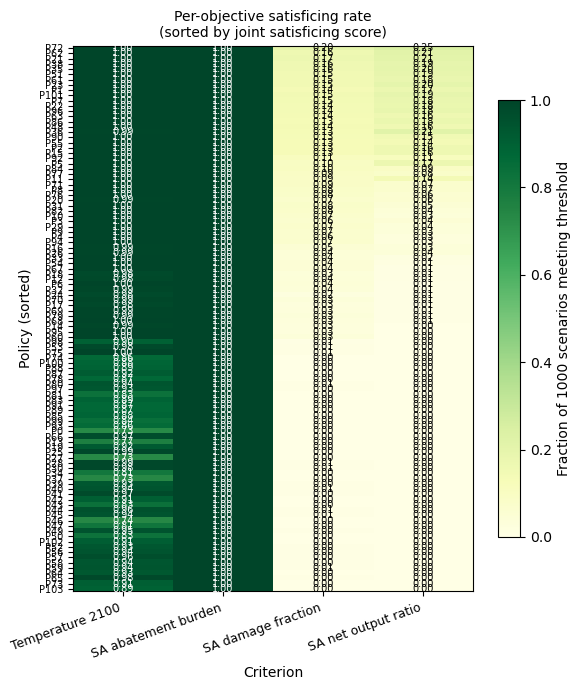

Figure saved: plots/a07_satisficing_heatmap.png


In [46]:
import copy
# ── VISUALISATION ─────────────────────────────────────────────────────────────

# FIX 0: Selecteer alleen de 4 satisficing criteria
# PAS DEZE INDICES AAN als jullie 4 criteria niet de eerste 4 kolommen zijn.
SATISFICING_IDX = [0, 1, 2, 3]

results_crit = results[:, :, SATISFICING_IDX]   # shape: (n_policies, n_scenarios, 4)

# Labels voor alleen deze 4 criteria
# Als OBJ_LABELS al maar 4 labels heeft, laat dit zo:
OBJ_LABELS_CRIT = [
    "Temperature 2100",
    "SA abatement burden",
    "SA damage fraction",
    "SA net output ratio",
]


# Als OBJ_LABELS nog 10 labels heeft, gebruik dan deze regel in plaats van hierboven:
# OBJ_LABELS_CRIT = [OBJ_LABELS[i] for i in SATISFICING_IDX]


# FIX 1: Haal het aantal policies dynamisch uit de gefilterde resultaten
N_POLICIES = results_crit.shape[0]

# FIX 2: Zorg dat de plots-map bestaat
_PLOTS_DIR = "plots"
os.makedirs(_PLOTS_DIR, exist_ok=True)

# FIX 3: Thresholds alleen voor de 4 criteria
THRESHOLD_PERCENTILES = [95, 90, 5, 5]

assert results_crit.shape[-1] == len(THRESHOLD_PERCENTILES), (
    f"Mismatch: results_crit has {results_crit.shape[-1]} criteria, "
    f"but THRESHOLD_PERCENTILES has {len(THRESHOLD_PERCENTILES)} values."
)

assert len(OBJ_LABELS_CRIT) == results_crit.shape[-1], (
    f"Mismatch: OBJ_LABELS_CRIT has {len(OBJ_LABELS_CRIT)} labels, "
    f"but results_crit has {results_crit.shape[-1]} criteria."
)

flat = results_crit.reshape(-1, results_crit.shape[-1])

thresholds_arr = np.array([
    np.nanpercentile(flat[:, i], THRESHOLD_PERCENTILES[i])
    for i in range(results_crit.shape[-1])
])


def _draw_heatmap(ax, data, cmap, vmin, vmax, row_labels, col_labels, title, cbar_label):
    """imshow-based heatmap (avoids seaborn/matplotlib 3.14 deepcopy incompatibility)."""
    im = ax.imshow(
        data,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=9, rotation=20, ha="right")

    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=7)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            tc = "white" if v > (vmax - vmin) * 0.6 + vmin else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color=tc)

    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)
    ax.set_title(title, fontsize=10)


# ── Figure 1: Satisficing heatmap ─────────────────────────────────────────────

# Per-objective satisficing: alleen over de 4 criteria
per_obj_sat = np.nanmean(
    results_crit <= thresholds_arr[np.newaxis, np.newaxis, :],
    axis=1
)  # shape: (n_policies, 4)

# Joint satisficing score: policy voldoet aan ALLE 4 criteria tegelijk
joint_sat = np.all(
    results_crit <= thresholds_arr[np.newaxis, np.newaxis, :],
    axis=2
)  # shape: (n_policies, n_scenarios)

sat_score = np.nanmean(joint_sat, axis=1)  # shape: (n_policies,)

# Sort policies by joint satisficing score
sat_order = np.argsort(-sat_score)

fig, ax = plt.subplots(figsize=(6, 7))

_draw_heatmap(
    ax,
    per_obj_sat[sat_order],
    "YlGn",
    0,
    1,
    [f"P{sat_order[i]}" for i in range(N_POLICIES)],
    OBJ_LABELS_CRIT,
    "Per-objective satisficing rate\n(sorted by joint satisficing score)",
    f"Fraction of {results_crit.shape[1]} scenarios meeting threshold",
)

ax.set_xlabel("Criterion")
ax.set_ylabel("Policy (sorted)")
plt.tight_layout()

display(fig)

plt.savefig(
    os.path.join(_PLOTS_DIR, "a07_satisficing_heatmap.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.close(fig)

print("Figure saved: plots/a07_satisficing_heatmap.png")

Showing top 15 policies:
 1. P72 | joint satisficing score = 0.169
 2. P62 | joint satisficing score = 0.139
 3. P21 | joint satisficing score = 0.138
 4. P38 | joint satisficing score = 0.131
 5. P35 | joint satisficing score = 0.131
 6. P51 | joint satisficing score = 0.130
 7. P61 | joint satisficing score = 0.126
 8. P23 | joint satisficing score = 0.124
 9. P1 | joint satisficing score = 0.121
10. P101 | joint satisficing score = 0.120
11. P7 | joint satisficing score = 0.118
12. P22 | joint satisficing score = 0.118
13. P96 | joint satisficing score = 0.117
14. P63 | joint satisficing score = 0.116
15. P86 | joint satisficing score = 0.115


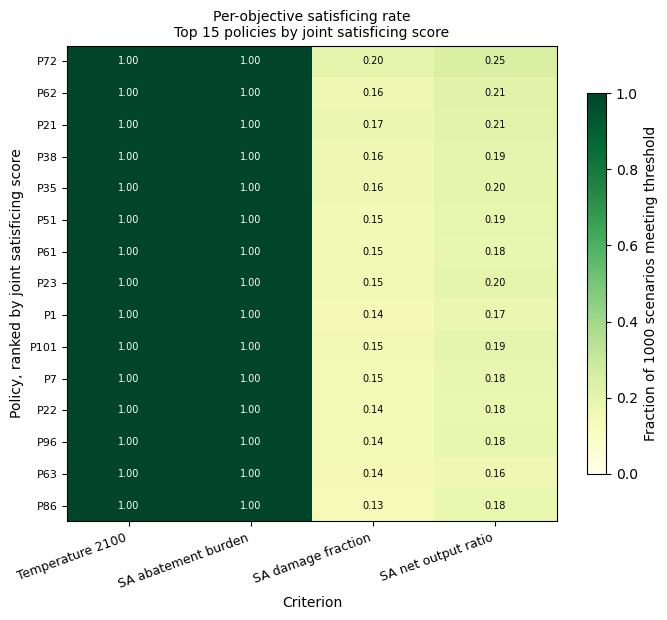

Figure saved: plots/a07_satisficing_heatmap_top15.png


In [55]:
import copy

# ── VISUALISATION ─────────────────────────────────────────────────────────────

# FIX 0: Selecteer alleen de 4 satisficing criteria
SATISFICING_IDX = [0, 1, 2, 3]

results_crit = results[:, :, SATISFICING_IDX]
# shape: (n_policies, n_scenarios, 4)

OBJ_LABELS_CRIT = [
    "Temperature 2100",
    "SA abatement burden",
    "SA damage fraction",
    "SA net output ratio",
]

# Number of policies in the full result set
N_POLICIES = results_crit.shape[0]

# Number of policies to show
TOP_N = min(15, N_POLICIES)

# Ensure plots folder exists
_PLOTS_DIR = "plots"
os.makedirs(_PLOTS_DIR, exist_ok=True)

# Thresholds for the 4 criteria
THRESHOLD_PERCENTILES = [95, 90, 5, 5]

assert results_crit.shape[-1] == len(THRESHOLD_PERCENTILES), (
    f"Mismatch: results_crit has {results_crit.shape[-1]} criteria, "
    f"but THRESHOLD_PERCENTILES has {len(THRESHOLD_PERCENTILES)} values."
)

assert len(OBJ_LABELS_CRIT) == results_crit.shape[-1], (
    f"Mismatch: OBJ_LABELS_CRIT has {len(OBJ_LABELS_CRIT)} labels, "
    f"but results_crit has {results_crit.shape[-1]} criteria."
)

flat = results_crit.reshape(-1, results_crit.shape[-1])

thresholds_arr = np.array([
    np.nanpercentile(flat[:, i], THRESHOLD_PERCENTILES[i])
    for i in range(results_crit.shape[-1])
])


def _draw_heatmap(
    ax,
    data,
    cmap,
    vmin,
    vmax,
    row_labels,
    col_labels,
    title,
    cbar_label,
):
    """imshow-based heatmap."""

    im = ax.imshow(
        data,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(
        col_labels,
        fontsize=9,
        rotation=20,
        ha="right",
    )

    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]

            tc = (
                "white"
                if v > (vmax - vmin) * 0.6 + vmin
                else "black"
            )

            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color=tc,
            )

    plt.colorbar(
        im,
        ax=ax,
        label=cbar_label,
        shrink=0.8,
    )

    ax.set_title(title, fontsize=10)


# ── Calculate satisficing scores ──────────────────────────────────────────────

per_obj_sat = np.nanmean(
    results_crit <= thresholds_arr[np.newaxis, np.newaxis, :],
    axis=1,
)
# shape: (n_policies, 4)

joint_sat = np.all(
    results_crit <= thresholds_arr[np.newaxis, np.newaxis, :],
    axis=2,
)
# shape: (n_policies, n_scenarios)

sat_score = np.nanmean(
    joint_sat,
    axis=1,
)
# shape: (n_policies,)

# Sort all policies by joint satisficing score
sat_order = np.argsort(-sat_score)

# Keep only the top 15
top_policy_idx = sat_order[:TOP_N]

print(f"Showing top {TOP_N} policies:")
for rank, policy_idx in enumerate(top_policy_idx, start=1):
    print(
        f"{rank:2d}. P{policy_idx} "
        f"| joint satisficing score = {sat_score[policy_idx]:.3f}"
    )


# ── Figure: top-15 satisficing heatmap ────────────────────────────────────────

fig_height = max(5, 0.42 * TOP_N)

fig, ax = plt.subplots(
    figsize=(7, fig_height)
)

_draw_heatmap(
    ax=ax,
    data=per_obj_sat[top_policy_idx],
    cmap="YlGn",
    vmin=0,
    vmax=1,
    row_labels=[
        f"P{policy_idx}"
        for policy_idx in top_policy_idx
    ],
    col_labels=OBJ_LABELS_CRIT,
    title=(
        f"Per-objective satisficing rate\n"
        f"Top {TOP_N} policies by joint satisficing score"
    ),
    cbar_label=(
        f"Fraction of {results_crit.shape[1]} "
        f"scenarios meeting threshold"
    ),
)

ax.set_xlabel("Criterion")
ax.set_ylabel("Policy, ranked by joint satisficing score")

plt.tight_layout()

plot_path = os.path.join(
    _PLOTS_DIR,
    "a07_satisficing_heatmap_top15.png",
)

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved: {plot_path}")

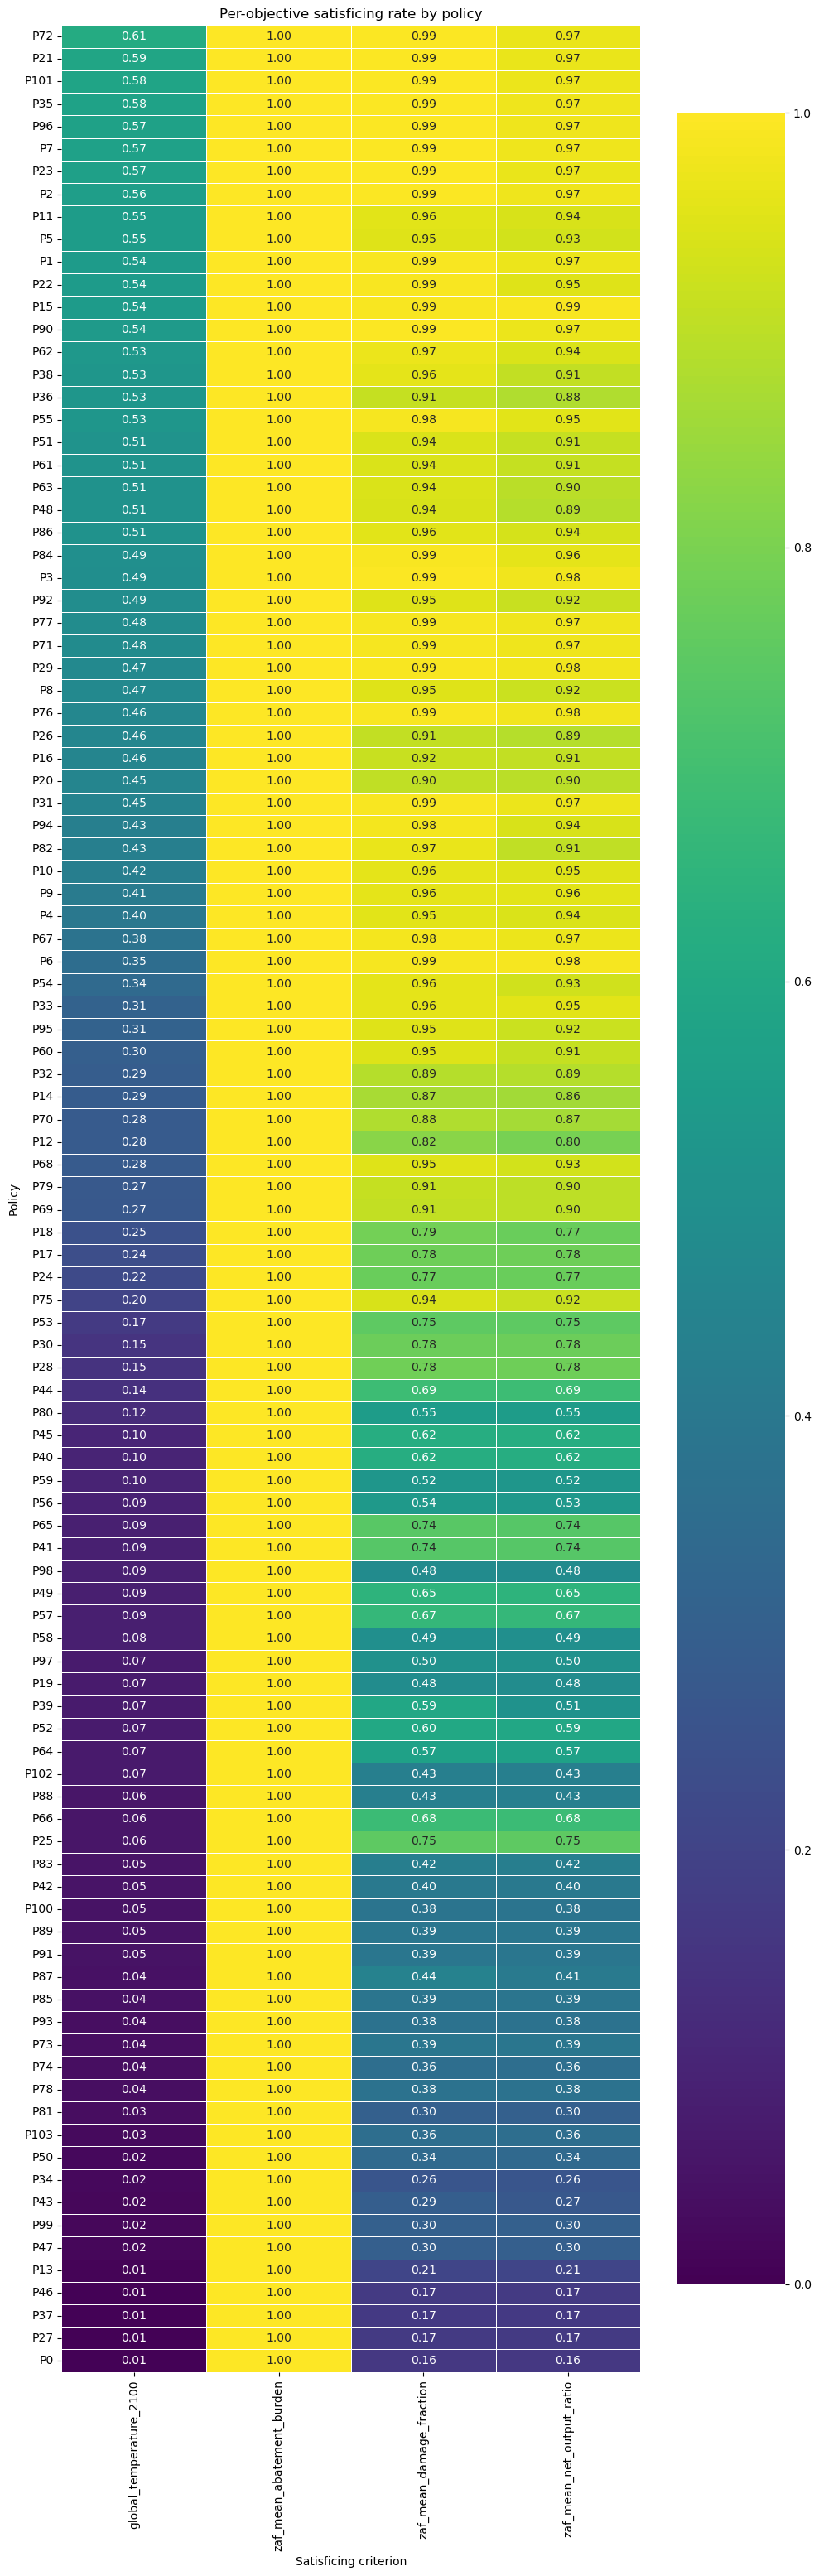

In [59]:
# ── SATISFICING HEATMAP VOOR 4 THRESHOLD-CRITERIA ────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Alle 10 model outcomes, in exact dezelfde volgorde als in results[:, :, :]
OBJECTIVES = [
    "welfare",
    "fraction_above_threshold",
    "global_temperature_2100",
    "max_global_temperature",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_mean_net_output_ratio",
]

# Alleen deze 4 gebruiken we als satisficing criteria
THRESHOLDS = {
    "global_temperature_2100": 2.0,
    "zaf_mean_abatement_burden": 0.05,
    "zaf_mean_damage_fraction": 0.05,
    "zaf_mean_net_output_ratio": 0.95,
}

# Alleen de objectives waarvoor jullie een threshold hebben
SATISFICING_OBJECTIVES = list(THRESHOLDS.keys())

# Vind de juiste kolommen in results
SATISFICING_IDX = [OBJECTIVES.index(obj) for obj in SATISFICING_OBJECTIVES]

# Selecteer alleen deze 4 criteria
results_crit = results[:, :, SATISFICING_IDX]

# Thresholds in dezelfde volgorde als SATISFICING_OBJECTIVES
thresholds_arr = np.array([
    THRESHOLDS[obj] for obj in SATISFICING_OBJECTIVES
])

# Richting per criterium:
# True  = lager is beter, dus <= threshold
# False = hoger is beter, dus >= threshold
LESS_IS_BETTER = np.array([
    True,   # global_temperature_2100 <= 2.0
    True,   # zaf_mean_abatement_burden <= 0.05
    True,   # zaf_mean_damage_fraction <= 0.05
    False,  # zaf_mean_net_output_ratio >= 0.95
])

# Check of alles dezelfde lengte heeft
assert results_crit.shape[-1] == len(SATISFICING_OBJECTIVES)
assert results_crit.shape[-1] == len(thresholds_arr)
assert results_crit.shape[-1] == len(LESS_IS_BETTER)

# Maak satisficing matrix
satisficing = np.empty_like(results_crit, dtype=bool)

for i in range(results_crit.shape[-1]):
    if LESS_IS_BETTER[i]:
        satisficing[:, :, i] = results_crit[:, :, i] <= thresholds_arr[i]
    else:
        satisficing[:, :, i] = results_crit[:, :, i] >= thresholds_arr[i]

# Per policy: percentage scenario's waarin elk criterium gehaald wordt
policy_objective_rates = np.nanmean(satisficing, axis=1)

# Joint satisficing: policy haalt alle 4 criteria tegelijk
joint_sat = np.all(satisficing, axis=2)
sat_score = np.nanmean(joint_sat, axis=1)

# DataFrame voor heatmap
heatmap_df = pd.DataFrame(
    policy_objective_rates,
    columns=SATISFICING_OBJECTIVES,
    index=[f"P{i}" for i in range(results.shape[0])]
)

heatmap_df["joint_sat"] = sat_score
heatmap_df = heatmap_df.sort_values("joint_sat", ascending=False)

# Plot
plt.figure(figsize=(10, max(6, 0.3 * results.shape[0])))

sns.heatmap(
    heatmap_df[SATISFICING_OBJECTIVES],
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.xlabel("Satisficing criterion")
plt.ylabel("Policy")
plt.title("Per-objective satisficing rate by policy")
plt.tight_layout()
plt.show()

In [ ]:
#PRIM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ema_workbench.analysis import prim

In [71]:
# ============================================================
# LOAD RESULTS AND EXPERIMENTS
# ============================================================

results = np.load(
    os.path.join(
        RESULTS_DIR,
        "reeval_prioritarian_zafmetrics_104p_1000s.npy"
    )
)

experiments = pd.read_csv(
    os.path.join(
        RESULTS_DIR,
        "reeval_prioritarian_zafmetrics_104p_1000s_experiments.csv"
    )
)

print("results shape:", results.shape)
print("experiments shape:", experiments.shape)

n_policies, n_scenarios, n_objectives = results.shape

print("n_policies:", n_policies)
print("n_scenarios:", n_scenarios)
print("n_objectives:", n_objectives)

display(experiments.head())

results shape: (104, 1000, 10)
experiments shape: (104000, 248)
n_policies: 104
n_scenarios: 1000
n_objectives: 10


,climate_ensemble_index,center_0,center_1,center_2,center_3,center_4,center_5,center_6,center_7,radii_0,...,weights_221,weights_222,weights_223,weights_224,weights_225,weights_226,weights_227,scenario,policy,model
0,1,-1.0,-0.090395,1.0,-1.0,1.0,-0.054657,-0.349492,-0.894873,1.0,...,0.942398,0.580223,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,0.513479,FAIR_1,P0,JUSTICEreeval
1,2,-1.0,-0.090395,1.0,-1.0,1.0,-0.054657,-0.349492,-0.894873,1.0,...,0.942398,0.580223,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,0.513479,FAIR_2,P0,JUSTICEreeval
2,3,-1.0,-0.090395,1.0,-1.0,1.0,-0.054657,-0.349492,-0.894873,1.0,...,0.942398,0.580223,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,0.513479,FAIR_3,P0,JUSTICEreeval
3,4,-1.0,-0.090395,1.0,-1.0,1.0,-0.054657,-0.349492,-0.894873,1.0,...,0.942398,0.580223,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,0.513479,FAIR_4,P0,JUSTICEreeval
4,5,-1.0,-0.090395,1.0,-1.0,1.0,-0.054657,-0.349492,-0.894873,1.0,...,0.942398,0.580223,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,0.513479,FAIR_5,P0,JUSTICEreeval


In [72]:
OBJECTIVES = [
    "welfare",
    "fraction_above_threshold",
    "global_temperature_2100",
    "max_global_temperature",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_net_output_ratio",
]

assert len(OBJECTIVES) == results.shape[2]

In [73]:
summary = pd.DataFrame({
    "objective": OBJECTIVES,
    "min": np.nanmin(results, axis=(0, 1)),
    "mean": np.nanmean(results, axis=(0, 1)),
    "max": np.nanmax(results, axis=(0, 1)),
})

display(summary)

,objective,min,mean,max
0,welfare,4.098994e+02,412.542336,423.883775
1,fraction_above_threshold,0.000000e+00,0.730135,1.000000
2,global_temperature_2100,1.028050e+00,2.418996,5.653989
3,max_global_temperature,1.326359e+00,3.830014,13.277496
4,welfare_loss_damage,1.297963e+04,47443.875322,216333.428713
5,welfare_loss_abatement,1.294872e+04,64180.764814,166609.959705
6,abatement_burden,4.772731e-07,0.004195,0.015864
7,zaf_mean_abatement_burden,1.398242e-07,0.002611,0.012125
8,zaf_mean_damage_fraction,-1.085430e-03,0.038848,0.179925
9,zaf_net_output_ratio,8.200748e-01,0.958542,0.998039


In [74]:
# ============================================================
# DEFINE SOUTH AFRICA SATISFICING CRITERIA
# ============================================================

TEMP_2100_THRESHOLD = 2.0
ZAF_ABATEMENT_BURDEN_THRESHOLD = 0.05
ZAF_DAMAGE_FRACTION_THRESHOLD = 0.05
ZAF_NET_OUTPUT_RATIO_THRESHOLD = 0.95

global_temperature_2100 = results[:, :, OBJECTIVES.index("global_temperature_2100")]
zaf_abatement_burden = results[:, :, OBJECTIVES.index("zaf_mean_abatement_burden")]
zaf_damage_fraction = results[:, :, OBJECTIVES.index("zaf_mean_damage_fraction")]
zaf_net_output_ratio = results[:, :, OBJECTIVES.index("zaf_net_output_ratio")]

SA_satisficing = np.stack(
    [
        global_temperature_2100 <= TEMP_2100_THRESHOLD,
        zaf_abatement_burden <= ZAF_ABATEMENT_BURDEN_THRESHOLD,
        zaf_damage_fraction <= ZAF_DAMAGE_FRACTION_THRESHOLD,
        zaf_net_output_ratio >= ZAF_NET_OUTPUT_RATIO_THRESHOLD,
    ],
    axis=2
)

print("SA_satisficing shape:", SA_satisficing.shape)

SA_satisficing shape: (104, 1000, 4)


In [75]:
# ============================================================
# ROBUSTNESS PER POLICY
# ============================================================

joint_satisficing = np.all(SA_satisficing, axis=2)
sat_score = joint_satisficing.mean(axis=1)

robustness_df = pd.DataFrame({
    "policy_id": np.arange(n_policies),
    "policy": [f"P{i}" for i in range(n_policies)],
    "joint_satisficing_robustness": sat_score,
})

robustness_df = robustness_df.sort_values(
    "joint_satisficing_robustness",
    ascending=False
)

display(robustness_df.head(15))

,policy_id,policy,joint_satisficing_robustness
72,72,P72,0.612
21,21,P21,0.588
101,101,P101,0.585
35,35,P35,0.577
96,96,P96,0.572
7,7,P7,0.570
23,23,P23,0.566
2,2,P2,0.557
11,11,P11,0.550
5,5,P5,0.547


In [76]:
# ============================================================
# PREPARE X FOR PRIM FOR ONE POLICY
# ============================================================

POLICY_ID = int(robustness_df.iloc[0]["policy_id"])  # meest robuuste policy
POLICY_LABEL = f"P{POLICY_ID}"

print("Selected policy:", POLICY_LABEL)

policy_experiments = experiments.loc[
    experiments["policy"] == POLICY_LABEL
].copy()

print("policy_experiments shape:", policy_experiments.shape)

if len(policy_experiments) != n_scenarios:
    raise ValueError(
        f"Expected {n_scenarios} rows for {POLICY_LABEL}, "
        f"but got {len(policy_experiments)}."
    )

display(policy_experiments.head())

Selected policy: P72
policy_experiments shape: (1000, 248)


,climate_ensemble_index,center_0,center_1,center_2,center_3,center_4,center_5,center_6,center_7,radii_0,...,weights_221,weights_222,weights_223,weights_224,weights_225,weights_226,weights_227,scenario,policy,model
72000,1,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_1,P72,JUSTICEreeval
72001,2,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_2,P72,JUSTICEreeval
72002,3,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_3,P72,JUSTICEreeval
72003,4,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_4,P72,JUSTICEreeval
72004,5,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_5,P72,JUSTICEreeval


In [77]:
# ============================================================
# SELECT UNCERTAINTY COLUMNS FOR PRIM
# ============================================================

UNCERTAINTY_COLS = [
    "climate_ensemble_index"
]

X_prim = policy_experiments[UNCERTAINTY_COLS].copy()
X_prim = X_prim.reset_index(drop=True)

print("X_prim shape:", X_prim.shape)
display(X_prim.head())

X_prim shape: (1000, 1)


,climate_ensemble_index
0,1
1,2
2,3
3,4
4,5


In [78]:
# ============================================================
# DEFINE FAILURE LABEL FOR PRIM
# ============================================================

y_failure = ~np.all(SA_satisficing[POLICY_ID, :, :], axis=1)

print(f"Policy {POLICY_LABEL}")
print(f"Failures: {y_failure.sum()} out of {len(y_failure)}")
print(f"Failure rate: {100 * y_failure.mean():.1f}%")

if y_failure.sum() == 0:
    raise ValueError("This policy has no failures. PRIM cannot explain failures.")

if y_failure.sum() == len(y_failure):
    raise ValueError("This policy fails in all scenarios. PRIM cannot distinguish failure conditions.")

Policy P72
Failures: 388 out of 1000
Failure rate: 38.8%


In [81]:
# ============================================================
# RUN PRIM
# ============================================================

from ema_workbench.analysis import prim

prim_alg = prim.Prim(
    X_prim,
    y_failure
)

box = prim_alg.find_box()

In [93]:
# ============================================================
# DEFINE FAILURE LABEL FOR PRIM
# ============================================================

POLICY_ID = 72
POLICY_LABEL = f"P{POLICY_ID}"

# Een scenario faalt als niet alle satisficing criteria gehaald worden
y_failure = ~np.all(SA_satisficing[POLICY_ID, :, :], axis=1)

print(f"Policy {POLICY_LABEL}")
print(f"Number of failures: {y_failure.sum()} out of {len(y_failure)} ({100*y_failure.mean():.1f}%)")

Policy P72
Number of failures: 388 out of 1000 (38.8%)


In [94]:
# ============================================================
# SELECT POLICY FOR PRIM
# ============================================================

POLICY_ID = int(robustness_df.iloc[0]["policy_id"])
POLICY_LABEL = f"P{POLICY_ID}"

print("Selected policy:", POLICY_LABEL)

policy_experiments = experiments.loc[
    experiments["policy"] == POLICY_LABEL
].copy()

# Zorg dat de scenario-volgorde overeenkomt met results[:, scenario, :]
policy_experiments = policy_experiments.sort_values(
    "climate_ensemble_index"
).reset_index(drop=True)

print("policy_experiments shape:", policy_experiments.shape)

if len(policy_experiments) != n_scenarios:
    raise ValueError(
        f"Expected {n_scenarios} rows for {POLICY_LABEL}, "
        f"but got {len(policy_experiments)}."
    )

display(policy_experiments.head())

Selected policy: P72
policy_experiments shape: (1000, 248)


,climate_ensemble_index,center_0,center_1,center_2,center_3,center_4,center_5,center_6,center_7,radii_0,...,weights_221,weights_222,weights_223,weights_224,weights_225,weights_226,weights_227,scenario,policy,model
0,1,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_1,P72,JUSTICEreeval
1,2,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_2,P72,JUSTICEreeval
2,3,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_3,P72,JUSTICEreeval
3,4,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_4,P72,JUSTICEreeval
4,5,0.180822,0.455237,0.187424,0.9182,0.119448,0.911614,0.207284,0.872115,0.130399,...,0.277705,0.664369,0.949388,0.97029,0.723282,0.746883,0.914593,FAIR_5,P72,JUSTICEreeval


In [95]:
# ============================================================
# DEFINE X FOR PRIM
# ============================================================

UNCERTAINTY_COLS = [
    "climate_ensemble_index"
]

X_prim = policy_experiments[UNCERTAINTY_COLS].copy()

print("X_prim shape:", X_prim.shape)
display(X_prim.head())

X_prim shape: (1000, 1)


,climate_ensemble_index
0,1
1,2
2,3
3,4
4,5


In [96]:
# ============================================================
# DEFINE BINARY FAILURE LABEL, LIKE IN THE LAB
# ============================================================

y = ~np.all(SA_satisficing[POLICY_ID, :, :], axis=1)

print(f"Policy {POLICY_LABEL}")
print(f"Number of failures: {y.sum()} out of {len(y)} ({100*y.mean():.1f}%)")

if y.sum() == 0:
    raise ValueError("This policy has no failures. PRIM cannot explain failures.")

if y.sum() == len(y):
    raise ValueError("This policy fails in all scenarios. PRIM cannot distinguish failure conditions.")

Policy P72
Number of failures: 388 out of 1000 (38.8%)


In [97]:
# ============================================================
# RUN PRIM
# ============================================================

prim_alg = prim.Prim(X_prim, y)

box = prim_alg.find_box()

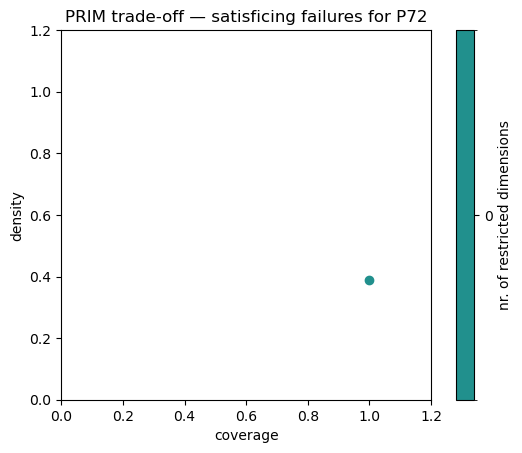

In [98]:
# ============================================================
# PRIM TRADE-OFF PLOT
# ============================================================

box.show_tradeoff()
plt.title(f"PRIM trade-off — satisficing failures for {POLICY_LABEL}")
plt.show()

In [99]:
# ============================================================
# INSPECT PEELING TRAJECTORY
# ============================================================

traj = box.peeling_trajectory.copy()

display(traj.head())
display(traj.tail())

,coverage,density,id,k,mass,mean,n,res_dim
0,1.0,0.388,0,388,1.0,0.388,1000,0


,coverage,density,id,k,mass,mean,n,res_dim
0,1.0,0.388,0,388,1.0,0.388,1000,0


In [100]:
# ============================================================
# SELECT PRIM BOX
# ============================================================

MIN_DENSITY = 0.8

candidates = traj[traj["density"] >= MIN_DENSITY]

if len(candidates) > 0:
    selected_box_index = int(candidates["coverage"].idxmax())
else:
    selected_box_index = int(traj["density"].idxmax())
    print(
        f"No box reached density >= {MIN_DENSITY}. "
        f"Using highest-density box instead."
    )

print("Selected box index:", selected_box_index)
print(traj.loc[selected_box_index, ["coverage", "density", "mass"]])

box.select(selected_box_index)

No box reached density >= 0.8. Using highest-density box instead.
Selected box index: 0
coverage    1.000
density     0.388
mass        1.000
Name: 0, dtype: float64


In [101]:
# ============================================================
# INSPECT SELECTED BOX
# ============================================================

box.inspect(style="table")

coverage       1.000
density        0.388
id             0.000
k            388.000
mass           1.000
mean           0.388
n           1000.000
res_dim        0.000
Name: 0, dtype: float64

Empty DataFrame
Columns: [(box 0, min), (box 0, max), (box 0, qp value), (box 0, qp value)]
Index: []



[None]

In [102]:
# ============================================================
# OPTIONAL PRIM EVENT: WORST 10% ZAF ABATEMENT BURDEN
# ============================================================

outcome = results[
    POLICY_ID,
    :,
    OBJECTIVES.index("zaf_mean_abatement_burden")
]

# Omdat hogere abatement burden slechter is, nemen we de 90th percentile
threshold = np.percentile(outcome, 90)

print(f"ZAF abatement burden 90th percentile: {threshold:.4f}")

y = outcome > threshold

print(f"Number of high-burden scenarios: {y.sum()} out of {len(y)} ({100*y.mean():.1f}%)")

ZAF abatement burden 90th percentile: 0.0114
Number of high-burden scenarios: 100 out of 1000 (10.0%)


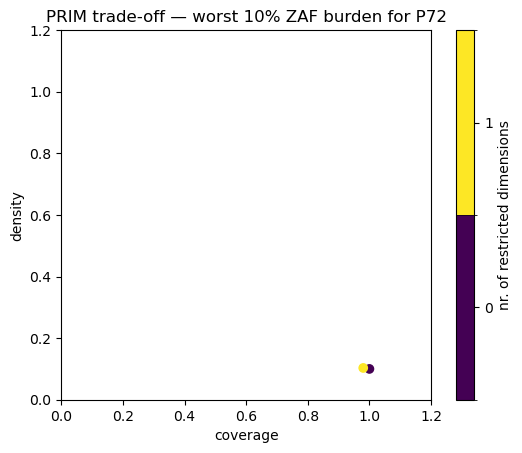

In [103]:
# ============================================================
# RUN PRIM FOR WORST 10% ZAF BURDEN
# ============================================================

prim_alg = prim.Prim(X_prim, y)

box = prim_alg.find_box()

box.show_tradeoff()
plt.title(f"PRIM trade-off — worst 10% ZAF burden for {POLICY_LABEL}")
plt.show()

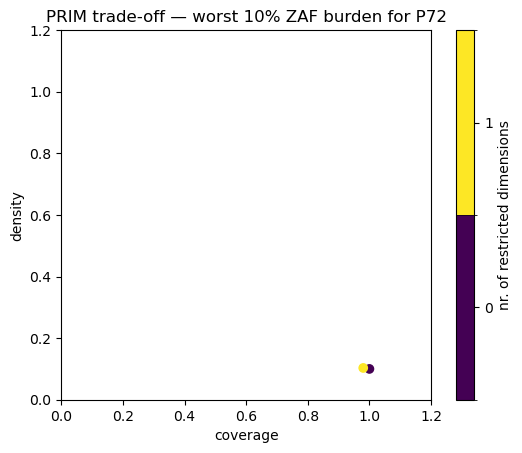

In [105]:
# ============================================================
# RUN PRIM FOR WORST 10% ZAF BURDEN
# ============================================================

prim_alg = prim.Prim(X_prim, y)

box = prim_alg.find_box()

box.show_tradeoff()
plt.title(f"PRIM trade-off — worst 10% ZAF burden for {POLICY_LABEL}")
plt.show()


In [104]:
traj = box.peeling_trajectory.copy()
display(traj.tail())

MIN_DENSITY = 0.8

candidates = traj[traj["density"] >= MIN_DENSITY]

if len(candidates) > 0:
    selected_box_index = int(candidates["coverage"].idxmax())
else:
    selected_box_index = int(traj["density"].idxmax())

box.select(selected_box_index)

print("Selected box index:", selected_box_index)
print(traj.loc[selected_box_index, ["coverage", "density", "mass"]])

box.inspect(style="table")

,coverage,density,id,k,mass,mean,n,res_dim
0,1.00,0.100000,0,100,1.00,0.100000,1000,0
1,0.98,0.103158,1,98,0.95,0.103158,950,1


Selected box index: 1
coverage    0.980000
density     0.103158
mass        0.950000
Name: 1, dtype: float64
coverage      0.980000
density       0.103158
id            1.000000
k            98.000000
mass          0.950000
mean          0.103158
n           950.000000
res_dim       1.000000
Name: 1, dtype: float64

                       box 1                          
                         min    max qp value  qp value
climate_ensemble_index   1.0  950.0      NaN  0.388325



[None]

In [ ]:
##klaar/?

Nieuwe poging (ECR mapping)

In [ ]:
ECR MAPPIBNG


In [ ]:
# ============================================================
# SELECT POLICIES FOR ECR MAPPING
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join(_PROJECT_DIR, "results")
RIVAL_RESULTS_DIR = os.path.join(_PROJECT_DIR, "results_rival")

ECR_MAP_DIR = os.path.join(RESULTS_DIR, "ecr_maps_selected_policies")
os.makedirs(ECR_MAP_DIR, exist_ok=True)

PLOTS_DIR = ECR_MAP_DIR


def find_file(folder, pattern):
    matches = glob.glob(os.path.join(folder, "**", pattern), recursive=True)
    if not matches:
        raise FileNotFoundError(f"No file found for pattern: {pattern} in {folder}")
    return max(matches, key=os.path.getmtime)


# ------------------------------------------------------------
# Load reference sets
# ------------------------------------------------------------

prio_ref_path = find_file(
    RESULTS_DIR,
    "reference_set_prioritarian_100000.csv"
)

try:
    uti_ref_path = find_file(
        RIVAL_RESULTS_DIR,
        "reference_set_utilitarian_100000.csv"
    )
except FileNotFoundError:
    uti_ref_path = find_file(
        RIVAL_RESULTS_DIR,
        "*UTILITARIAN*reference*.csv"
    )

prioritarian_ref = pd.read_csv(prio_ref_path)
utilitarian_ref = pd.read_csv(uti_ref_path)

print("Prioritarian reference set:", prio_ref_path, prioritarian_ref.shape)
print("Utilitarian reference set:", uti_ref_path, utilitarian_ref.shape)


# ------------------------------------------------------------
# Load summary tables
# ------------------------------------------------------------

prio_summary_path = find_file(
    RESULTS_DIR,
    "*prioritarian*summary*.csv"
)

uti_summary_path = find_file(
    RIVAL_RESULTS_DIR,
    "*utilitarian*summary*.csv"
)

prioritarian_summary = pd.read_csv(prio_summary_path)
utilitarian_summary = pd.read_csv(uti_summary_path)

print("Prioritarian summary:", prio_summary_path, prioritarian_summary.shape)
print("Utilitarian summary:", uti_summary_path, utilitarian_summary.shape)


# ------------------------------------------------------------
# Select policies
# ------------------------------------------------------------

def get_best_by_sa_criteria(summary_df):
    """
    Best policy according to South Africa satisficing robustness.
    """
    if "sa_robustness_score" in summary_df.columns:
        return int(
            summary_df.sort_values(
                "sa_robustness_score",
                ascending=False
            ).iloc[0]["policy_id"]
        )

    if "sa_temperature_robustness_score" in summary_df.columns:
        return int(
            summary_df.sort_values(
                "sa_temperature_robustness_score",
                ascending=False
            ).iloc[0]["policy_id"]
        )

    return int(summary_df.iloc[0]["policy_id"])


def get_best_by_utilitarian_logic(summary_df):
    """
    Best policy according to rival/utilitarian logic.
    Uses welfare if available.
    In our output lower welfare objective is better because it is minimized.
    """
    df = summary_df.copy()

    if "mean_welfare" in df.columns:
        return int(
            df.sort_values("mean_welfare", ascending=True)
            .iloc[0]["policy_id"]
        )

    if "median_welfare" in df.columns:
        return int(
            df.sort_values("median_welfare", ascending=True)
            .iloc[0]["policy_id"]
        )

    if "median_global_temperature_2100" in df.columns:
        return int(
            df.sort_values(
                "median_global_temperature_2100",
                ascending=True
            ).iloc[0]["policy_id"]
        )

    return int(df.iloc[0]["policy_id"])


best_prioritarian_sa_id = get_best_by_sa_criteria(prioritarian_summary)
best_utilitarian_sa_id = get_best_by_sa_criteria(utilitarian_summary)
best_utilitarian_rival_id = get_best_by_utilitarian_logic(utilitarian_summary)

print("Best Prioritarian under SA criteria:", best_prioritarian_sa_id)
print("Best Utilitarian under SA criteria:", best_utilitarian_sa_id)
print("Best Utilitarian under rival logic:", best_utilitarian_rival_id)


selected_ecr_policies = [
    {
        "label": "Prioritarian",
        "description": f"Prioritarian SA-compatible P{best_prioritarian_sa_id}",
        "framing": "Prioritarian",
        "policy_id": best_prioritarian_sa_id,
        "reference_set": prioritarian_ref,
    },
    {
        "label": "Utilitarian SA-compatible",
        "description": f"Utilitarian SA-compatible P{best_utilitarian_sa_id}",
        "framing": "Utilitarian",
        "policy_id": best_utilitarian_sa_id,
        "reference_set": utilitarian_ref,
    },
    {
        "label": "Utilitarian rival-preferred",
        "description": f"Utilitarian rival-preferred P{best_utilitarian_rival_id}",
        "framing": "Utilitarian",
        "policy_id": best_utilitarian_rival_id,
        "reference_set": utilitarian_ref,
    },
]

selected_ecr_df = pd.DataFrame([
    {
        "label": p["label"],
        "description": p["description"],
        "framing": p["framing"],
        "policy_id": p["policy_id"],
    }
    for p in selected_ecr_policies
])

display(selected_ecr_df)

selected_ecr_df.to_csv(
    os.path.join(ECR_MAP_DIR, "selected_ecr_policies.csv"),
    index=False
)

In [ ]:
# ============================================================
# RUN SELECTED POLICIES AND EXTRACT CONSTRAINED ECR + ABATEMENT BURDEN
# ============================================================

from solvers.emodps.rbf import RBF
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.enumerations import (
    Economy,
    DamageFunction,
    Abatement,
    WelfareFunction,
)

# Settings
REFERENCE_SCENARIO = 2
CLIMATE_ENSEMBLE_FOR_ECR = 1

EMISSION_CONTROL_START_YEAR = 2025
MAX_ANNUAL_GROWTH_RATE = 0.04
MIN_EMISSION_CONTROL_RATE = 0.01

snap_year = 2100
snap_ts = snap_year - START_YEAR

_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0, 0.0


def build_rbf_from_policy_row(policy_row):
    """
    Builds an RBF from one policy row in the reference set.
    """

    rbf = RBF(
        n_rbfs=N_RBFS,
        n_inputs=N_INPUTS,
        n_outputs=N_REGIONS,
    )

    center_cols = [c for c in policy_row.index if str(c).startswith("center")]
    radii_cols = [c for c in policy_row.index if str(c).startswith("radii")]
    weight_cols = [c for c in policy_row.index if str(c).startswith("weights")]

    def col_num(c):
        return int(str(c).split()[-1])

    center_cols = sorted(center_cols, key=col_num)
    radii_cols = sorted(radii_cols, key=col_num)
    weight_cols = sorted(weight_cols, key=col_num)

    centers = policy_row[center_cols].astype(float).to_numpy()
    radii = policy_row[radii_cols].astype(float).to_numpy()
    weights = policy_row[weight_cols].astype(float).to_numpy()

    radii = np.maximum(radii, SMALL_NUMBER)
    weights = np.maximum(weights, SMALL_NUMBER)

    rbf.set_decision_vars(
        np.concatenate([centers, radii, weights])
    )

    return rbf


def run_policy_extract_ecr(policy_row, framing):
    """
    Runs one selected policy and returns:
    - constrained_ecr: regions x timesteps x ensembles
    - abatement_burden: regions x timesteps x ensembles
    """

    JUSTICE.hard_reset()

    welfare_function = (
        WelfareFunction.PRIORITARIAN
        if framing == "Prioritarian"
        else WelfareFunction.UTILITARIAN
    )

    rbf = build_rbf_from_policy_row(policy_row)

    model = JUSTICE(
        start_year=START_YEAR,
        end_year=END_YEAR,
        timestep=TIMESTEP,
        scenario=REFERENCE_SCENARIO,
        climate_ensembles=[CLIMATE_ENSEMBLE_FOR_ECR],
        stochastic_run=False,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function=welfare_function,
    )

    emission_control_start_timestep = EMISSION_CONTROL_START_YEAR - START_YEAR

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=MAX_ANNUAL_GROWTH_RATE,
        emission_control_start_timestep=emission_control_start_timestep,
        min_emission_control_rate=MIN_EMISSION_CONTROL_RATE,
    )

    no_of_ensembles = model.no_of_ensembles

    ecr = np.zeros((N_REGIONS, N_TIMESTEPS, no_of_ensembles))
    constrained_ecr = np.zeros_like(ecr)

    previous_temperature = 0.0
    difference = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :],
            t,
            allow_fallback=False,
        )

        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )

        data_step = model.stepwise_evaluate(timestep=t)
        temperature = data_step["global_temperature"][t, :]

        if t % 5 == 0:
            difference = temperature - previous_temperature
            previous_temperature = temperature.copy()

        temp_safe = np.nan_to_num(
            temperature,
            nan=_MAX_TEMP,
            posinf=_MAX_TEMP,
            neginf=_MIN_TEMP,
        )

        diff_safe = np.nan_to_num(
            difference,
            nan=_MAX_DIFF,
            posinf=_MAX_DIFF,
            neginf=_MIN_DIFF,
        )

        scaled_temp = (temp_safe - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff_safe - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        scaled_temp = np.clip(scaled_temp, 0.0, 1.0)
        scaled_diff = np.clip(scaled_diff, 0.0, 1.0)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(
                np.array([scaled_temp, scaled_diff])
            )

    # Only evaluate after the full time loop is finished
    data = model.evaluate()

    gross_output = data["gross_economic_output"]
    abatement_cost = data["abatement_cost"]

    abatement_burden = np.divide(
        abatement_cost,
        np.maximum(gross_output, SMALL_NUMBER)
    )

    return constrained_ecr, abatement_burden


# ============================================================
# RUN LOOP
# ============================================================

ecr_full = {}
ecr_end = {}

abatement_burden_full = {}
abatement_burden_end = {}

for spec in selected_ecr_policies:
    label = spec["label"]
    policy_id = spec["policy_id"]
    ref = spec["reference_set"]
    framing = spec["framing"]

    print(f"Running ECR + abatement burden extraction for: {label} | policy {policy_id}")

    policy_row = ref.iloc[int(policy_id)]

    constrained_ecr, abatement_burden = run_policy_extract_ecr(
        policy_row=policy_row,
        framing=framing,
    )

    ecr_full[label] = constrained_ecr
    ecr_end[label] = np.nanmean(
        constrained_ecr[:, snap_ts, :],
        axis=1
    )

    abatement_burden_full[label] = abatement_burden
    abatement_burden_end[label] = np.nanmean(
        abatement_burden[:, snap_ts, :],
        axis=1
    )

print("Finished ECR + abatement burden extraction.")

for label in ecr_end.keys():
    print("\n", label)

    print(
        "ECR 2100:",
        "shape:", ecr_end[label].shape,
        "min:", np.nanmin(ecr_end[label]),
        "max:", np.nanmax(ecr_end[label]),
        "mean:", np.nanmean(ecr_end[label]),
    )

    print(
        "Abatement burden 2100:",
        "shape:", abatement_burden_end[label].shape,
        "min:", np.nanmin(abatement_burden_end[label]),
        "max:", np.nanmax(abatement_burden_end[label]),
        "mean:", np.nanmean(abatement_burden_end[label]),
    )

In [ ]:
# ============================================================
# CREATE WORLD AND REGIONS_GDF FOR ECR MAP
# ============================================================

import os
import json as _json
import pathlib
import importlib.util
import geopandas as gpd

# Path to RICE50 region dictionary
_rice50_dict_path = os.path.join(
    _JUSTICE_ROOT,
    "data",
    "input",
    "rice50_regions_dict.json"
)

with open(_rice50_dict_path) as _f:
    _rice50_dict = _json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France": "fra",
    "Norway": "nor",
    "Kosovo": "oeu",
    "N. Cyprus": "tur",
    "Somaliland": "rsaf",
}

# Load world shapefile from pyogrio's built-in Natural Earth example data
_pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(
    _pyogrio_path
    / "tests"
    / "fixtures"
    / "naturalearth_lowres"
    / "naturalearth_lowres.shp"
)

world = gpd.read_file(_ne_shp)

# Map countries to RICE50 regions
world["rice50"] = world["iso_a3"].map(iso_to_rice50)

mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = (
    world.loc[mask_missing, "name"].map(_name_fallback)
)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# Dissolve countries into RICE50 regions
regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"]]

regions_gdf = gpd.GeoDataFrame(
    regions_gdf,
    geometry="geometry",
    crs=world.crs
)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")
print("regions_gdf columns:", list(regions_gdf.columns))
display(regions_gdf.head())

In [ ]:
# ============================================================
# ADD ECR VALUES TO MAP GEODATAFRAME
# ============================================================

print("regions_gdf columns:")
print(list(regions_gdf.columns))

# Pas dit aan als jouw kolom anders heet.
# Hij moet codes bevatten zoals 'zaf', 'usa', 'chn', etc.
possible_region_cols = [
    "region",
    "region_code",
    "RICE50",
    "rice50",
    "rice50_region",
    "name",
]

REGION_CODE_COL = "rice50"

for col in possible_region_cols:
    if col in regions_gdf.columns:
        sample_vals = set(regions_gdf[col].dropna().astype(str).str.lower().head(20))
        if any(code in sample_vals for code in ["zaf", "usa", "chn", "gbr", "rfa"]):
            REGION_CODE_COL = col
            break

if REGION_CODE_COL is None:
    raise KeyError(
        "Could not automatically find the region-code column in regions_gdf. "
        "Check regions_gdf.columns and set REGION_CODE_COL manually."
    )

print("Using region code column:", REGION_CODE_COL)

region_to_idx = {
    region_code: idx
    for idx, region_code in enumerate(REGION_LIST)
}

for label, values in ecr_end.items():
    col = f"ecr_{label}"

    regions_gdf[col] = (
        regions_gdf[REGION_CODE_COL]
        .astype(str)
        .str.lower()
        .map(
            lambda r: values[region_to_idx[r]]
            if r in region_to_idx
            else np.nan
        )
    )

print("Added ECR columns:")
print([c for c in regions_gdf.columns if c.startswith("ecr_")])

In [ ]:
# ============================================================
# WORLD MAP — ECR SNAPSHOT FOR SELECTED POLICIES
# ============================================================

import matplotlib.colors as mcolors
from IPython.display import Image, display

panel_specs = [
    (f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})")
    for label in ecr_end.keys()
]

all_vals = pd.concat([
    regions_gdf[col].dropna()
    for col, _ in panel_specs
])

vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

n_panels = len(panel_specs)

fig, axes = plt.subplots(
    1,
    n_panels,
    figsize=(6 * n_panels, 6)
)

if n_panels == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]

    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="horizontal",
        pad=0.02,
        shrink=0.75,
        aspect=35
    )

    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

fig.suptitle(
    f"Regional Emission Control Rate in {snap_year}\n"
    "Selected Prioritarian and Utilitarian Policies — JUSTICE RICE50 Model",
    fontsize=13,
    y=1.02
)

plt.tight_layout()

ecr_map_path = os.path.join(
    PLOTS_DIR,
    f"ecr_regional_map_selected_policies_{snap_year}.png"
)

plt.savefig(
    ecr_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(Image(filename=ecr_map_path))

print("Saved:", ecr_map_path)

In [ ]:
# ============================================================
# ADD ABATEMENT BURDEN VALUES TO MAP GEODATAFRAME
# ============================================================

REGION_CODE_COL = "rice50"

region_to_idx = {
    region_code: idx
    for idx, region_code in enumerate(REGION_LIST)
}

for label, values in abatement_burden_end.items():
    col = f"burden_{label}"

    regions_gdf[col] = (
        regions_gdf[REGION_CODE_COL]
        .astype(str)
        .str.lower()
        .map(
            lambda r: values[region_to_idx[r]]
            if r in region_to_idx
            else np.nan
        )
    )

print("Added burden columns:")
print([c for c in regions_gdf.columns if c.startswith("burden_")])

display(regions_gdf.head())

In [ ]:
# ============================================================
# SECOND WORLD MAP — ABATEMENT BURDEN SNAPSHOT
# ============================================================

import matplotlib.colors as mcolors

panel_specs = [
    (f"burden_{label}", f"{label}\nAbatement burden ({snap_year})")
    for label in abatement_burden_end.keys()
]

all_vals = pd.concat([
    regions_gdf[col]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    for col, _ in panel_specs
])

vmin_all = 0.0
vmax_all = all_vals.quantile(0.95)

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

n_panels = len(panel_specs)

fig, axes = plt.subplots(
    1,
    n_panels,
    figsize=(6 * n_panels, 6)
)

if n_panels == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]

    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="horizontal",
        pad=0.02,
        shrink=0.75,
        aspect=35
    )

    cbar.set_label(
        "Abatement burden\n(abatement cost / gross economic output)",
        fontsize=8
    )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

fig.suptitle(
    f"Regional abatement burden in {snap_year}\n"
    "Selected Prioritarian and Utilitarian Policies — JUSTICE RICE50 Model",
    fontsize=13,
    y=1.02
)

plt.tight_layout()

burden_map_path = os.path.join(
    PLOTS_DIR,
    f"abatement_burden_regional_map_selected_policies_{snap_year}.png"
)

plt.savefig(
    burden_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", burden_map_path)